# Superstore Sales & Profitability Analytics
## with AI-Assisted Transaction Anomaly Detection

---

**Program:** IBM SkillBuild Data Analytics with AI — Academic Internship  
**Dataset:** Seven 11 Superstore (9,994 transactions | 21 columns | 2014–2017)  
**Tools:** Python · pandas · numpy · matplotlib · scikit-learn  
**AI Model:** Isolation Forest (Unsupervised Anomaly Detection)  

---

### Table of Contents
1. Library Imports & Configuration  
2. Dataset Loading  
3. Data Understanding  
4. Data Quality Checks  
5. Missing Value Analysis  
6. Duplicate Analysis  
7. Data Type Validation  
8. Date Conversion  
9. Feature Engineering  
10. Exploratory Data Analysis  
11. KPI Analysis  
12. Sales Analysis  
13. Profit Analysis  
14. Profit Margin Analysis  
15. Category Analysis  
16. Sub-Category Analysis  
17. Regional Analysis  
18. Customer Analysis  
19. Product Analysis  
20. Segment Analysis  
21. Monthly Sales Trend  
22. Monthly Profit Trend  
23. Discount vs Profit Analysis  
24. Loss-Making Transactions & Orders  
25. Top Customers  
26. Top Products  
27. AI Anomaly Detection — Isolation Forest  
28. Anomaly Visualization  
29. Business Insights  
30. Business Recommendations  
31. Final Conclusion  

---
## Section 1 — Library Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import warnings

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_colwidth', 60)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLORS = {
    'primary'  : '#2563EB',
    'profit'   : '#16A34A',
    'loss'     : '#DC2626',
    'accent'   : '#D97706',
    'muted'    : '#6B7280',
    'palette'  : ['#2563EB','#16A34A','#D97706','#7C3AED','#DB2777'],
    'gradient' : plt.cm.Blues
}

print('Libraries loaded successfully.')
print(f'  pandas      {pd.__version__}')
print(f'  numpy       {np.__version__}')
print(f'  matplotlib  {matplotlib.__version__}')
import sklearn; print(f'  scikit-learn {sklearn.__version__}')

Libraries loaded successfully.
  pandas      3.0.6
  numpy       2.5.3
  matplotlib  3.11.2
  scikit-learn 1.9.1


---
## Section 2 — Dataset Loading

In [13]:
CSV_PATH = 'Seven 11 Superstore.csv'

df = pd.read_csv(CSV_PATH, encoding='latin-1')

print('=== Dataset Loaded Successfully ===')
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print(f'\nColumn names:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col}')

print('\nFirst 3 rows:')
df.head(3)

=== Dataset Loaded Successfully ===
Rows    : 9,994
Columns : 21

Column names:
   1. Row ID
   2. Order ID
   3. Order Date
   4. Ship Date
   5. Ship Mode
   6. Customer ID
   7. Customer Name
   8. Segment
   9. Country
  10. City
  11. State
  12. Postal Code
  13. Region
  14. Product ID
  15. Category
  16. Sub-Category
  17. Product Name
  18. Sales
  19. Quantity
  20. Discount
  21. Profit

First 3 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back",731.94,3,0.00,219.58
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters by Universal,14.62,2,0.00,6.87


---
## Section 3 — Data Understanding

In [3]:
print('=== Shape ===')
print(f'{df.shape[0]:,} rows  x  {df.shape[1]} columns\n')

print('=== Data Types ===')
print(df.dtypes)

print('\n=== Statistical Summary (Numeric) ===')
df.describe()

=== Shape ===
9,994 rows  x  21 columns

=== Data Types ===
Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

=== Statistical Summary (Numeric) ===


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,4997.50,55190.38,229.86,3.79,0.16,28.66
std,2885.16,32063.69,623.25,2.23,0.21,234.26
min,1.00,1040.00,0.44,1.00,0.00,-6599.98
25%,2499.25,23223.00,17.28,2.00,0.00,1.73
50%,4997.50,56430.50,54.49,3.00,0.20,8.67
75%,7495.75,90008.00,209.94,5.00,0.20,29.36
max,9994.00,99301.00,22638.48,14.00,0.80,8399.98


In [4]:
print('=== Categorical Columns — Unique Values ===')
cat_cols = ['Ship Mode','Segment','Country','Region','Category','Sub-Category']
for col in cat_cols:
    vals = df[col].unique()
    print(f'\n{col} ({len(vals)} unique):')
    for v in sorted(vals):
        print(f'  · {v}')

=== Categorical Columns — Unique Values ===

Ship Mode (4 unique):
  · First Class
  · Same Day
  · Second Class
  · Standard Class

Segment (3 unique):
  · Consumer
  · Corporate
  · Home Office

Country (1 unique):
  · United States

Region (4 unique):
  · Central
  · East
  · South
  · West

Category (3 unique):
  · Furniture
  · Office Supplies
  · Technology

Sub-Category (17 unique):
  · Accessories
  · Appliances
  · Art
  · Binders
  · Bookcases
  · Chairs
  · Copiers
  · Envelopes
  · Fasteners
  · Furnishings
  · Labels
  · Machines
  · Paper
  · Phones
  · Storage
  · Supplies
  · Tables


---
## Section 4 — Data Quality Checks

In [5]:
print('=== Null Value Count per Column ===')
null_counts = df.isnull().sum()
print(null_counts[null_counts >= 0].to_string())

print('\n=== Negative Sales Check ===')
neg_sales = df[df['Sales'] < 0]
print(f'Rows with negative Sales : {len(neg_sales)}')

print('\n=== Discount Range Check (expected 0.0–1.0) ===')
out_disc = df[(df['Discount'] < 0) | (df['Discount'] > 1)]
print(f'Out-of-range Discount rows : {len(out_disc)}')

print('\n=== Quantity Range Check (expected > 0) ===')
bad_qty = df[df['Quantity'] <= 0]
print(f'Zero/negative Quantity rows : {len(bad_qty)}')

print('\n=== Data Quality Summary ===')
total_issues = len(neg_sales) + len(out_disc) + len(bad_qty) + df.isnull().sum().sum()
print(f'Total quality issues detected : {total_issues}')
if total_issues == 0:
    print('Dataset passes all quality checks.')

=== Null Value Count per Column ===
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0

=== Negative Sales Check ===
Rows with negative Sales : 0

=== Discount Range Check (expected 0.0–1.0) ===
Out-of-range Discount rows : 0

=== Quantity Range Check (expected > 0) ===
Zero/negative Quantity rows : 0

=== Data Quality Summary ===
Total quality issues detected : 0
Dataset passes all quality checks.


---
## Section 5 — Missing Value Analysis

=== Missing Value Report ===
               Missing Count  Missing %
Row ID                     0       0.00
Order ID                   0       0.00
Order Date                 0       0.00
Ship Date                  0       0.00
Ship Mode                  0       0.00
Customer ID                0       0.00
Customer Name              0       0.00
Segment                    0       0.00
Country                    0       0.00
City                       0       0.00
State                      0       0.00
Postal Code                0       0.00
Region                     0       0.00
Product ID                 0       0.00
Category                   0       0.00
Sub-Category               0       0.00
Product Name               0       0.00
Sales                      0       0.00
Quantity                   0       0.00
Discount                   0       0.00
Profit                     0       0.00


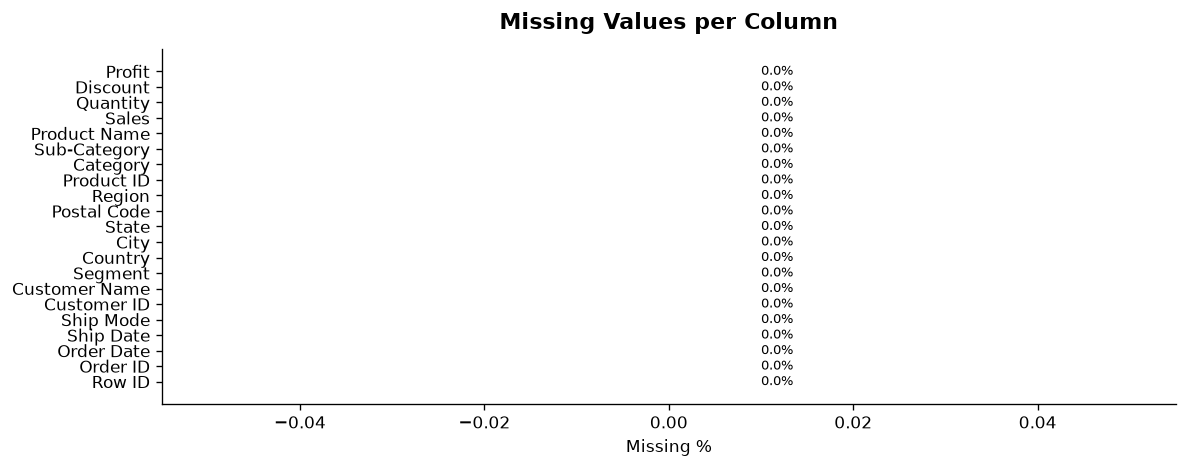


Conclusion: No missing values found.


In [6]:
missing = pd.DataFrame({
    'Missing Count'  : df.isnull().sum(),
    'Missing %'      : (df.isnull().sum() / len(df) * 100).round(2)
})
print('=== Missing Value Report ===')
print(missing.to_string())

# Visualise
fig, ax = plt.subplots(figsize=(10, 4))
missing_pct = missing['Missing %']
bars = ax.barh(missing_pct.index, missing_pct.values, color=COLORS['primary'], alpha=0.7)
ax.set_xlabel('Missing %')
ax.set_title('Missing Values per Column', fontsize=13, fontweight='bold', pad=12)
for bar, val in zip(bars, missing_pct.values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()
print('\nConclusion: No missing values found.' if missing_pct.sum() == 0
      else f'Missing values found — review required.')

---
## Section 6 — Duplicate Analysis

In [7]:
full_dupes = df.duplicated().sum()
row_dupes  = df.duplicated(subset=['Row ID']).sum()

print('=== Duplicate Analysis ===')
print(f'Fully duplicated rows       : {full_dupes}')
print(f'Duplicate Row IDs           : {row_dupes}')
print(f'Total unique Order IDs      : {df["Order ID"].nunique():,}')
print(f'Total unique Customer IDs   : {df["Customer ID"].nunique():,}')
print(f'Total unique Product IDs    : {df["Product ID"].nunique():,}')

if full_dupes == 0:
    print('\nNo duplicate rows detected. Dataset is clean.')
else:
    print(f'\nRemoving {full_dupes} duplicate rows...')
    df = df.drop_duplicates()
    print(f'Dataset size after dedup: {len(df):,} rows')

=== Duplicate Analysis ===
Fully duplicated rows       : 0
Duplicate Row IDs           : 0
Total unique Order IDs      : 5,009
Total unique Customer IDs   : 793
Total unique Product IDs    : 1,862

No duplicate rows detected. Dataset is clean.


---
## Section 7 — Data Type Validation

In [8]:
expected_types = {
    'Row ID'       : 'int64',
    'Order ID'     : 'object',
    'Order Date'   : 'object',   # will convert in Section 8
    'Ship Date'    : 'object',   # will convert in Section 8
    'Ship Mode'    : 'object',
    'Customer ID'  : 'object',
    'Customer Name': 'object',
    'Segment'      : 'object',
    'Country'      : 'object',
    'City'         : 'object',
    'State'        : 'object',
    'Postal Code'  : 'int64',
    'Region'       : 'object',
    'Product ID'   : 'object',
    'Category'     : 'object',
    'Sub-Category' : 'object',
    'Product Name' : 'object',
    'Sales'        : 'float64',
    'Quantity'     : 'int64',
    'Discount'     : 'float64',
    'Profit'       : 'float64',
}

print(f'{"Column":<20} {"Expected":<12} {"Actual":<12} {"Match"}')
print('-' * 55)
all_ok = True
for col, exp in expected_types.items():
    actual = str(df[col].dtype)
    match  = '✓' if actual == exp else '✗'
    if actual != exp:
        all_ok = False
    print(f'{col:<20} {exp:<12} {actual:<12} {match}')

print()
print('All data types validated successfully.' if all_ok
      else 'Some types differ — will be fixed during conversion.')

Column               Expected     Actual       Match
-------------------------------------------------------
Row ID               int64        int64        ✓
Order ID             object       str          ✗
Order Date           object       str          ✗
Ship Date            object       str          ✗
Ship Mode            object       str          ✗
Customer ID          object       str          ✗
Customer Name        object       str          ✗
Segment              object       str          ✗
Country              object       str          ✗
City                 object       str          ✗
State                object       str          ✗
Postal Code          int64        int64        ✓
Region               object       str          ✗
Product ID           object       str          ✗
Category             object       str          ✗
Sub-Category         object       str          ✗
Product Name         object       str          ✗
Sales                float64      float64      ✓
Quantity 

---
## Section 8 — Date Conversion

In [37]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%m/%d/%Y')

print('=== Date Conversion Complete ===')
print(f'Order Date dtype : {df["Order Date"].dtype}')
print(f'Ship Date  dtype : {df["Ship Date"].dtype}')
print(f'\nOrder Date range : {df["Order Date"].min().date()}  →  {df["Order Date"].max().date()}')
print(f'Ship Date  range : {df["Ship Date"].min().date()}  →  {df["Ship Date"].max().date()}')

# Assertion
assert pd.api.types.is_datetime64_any_dtype(df['Order Date']), 'Order Date conversion failed'
assert pd.api.types.is_datetime64_any_dtype(df['Ship Date']),  'Ship Date conversion failed'
print('\nAssertion checks passed.')

=== Date Conversion Complete ===
Order Date dtype : datetime64[us]
Ship Date  dtype : datetime64[us]

Order Date range : 2014-01-03  →  2017-12-30
Ship Date  range : 2014-01-07  →  2018-01-05

Assertion checks passed.


---
## Section 9 — Feature Engineering

In [15]:
# 1. Profit Margin %
df['Profit_Margin'] = (df['Profit'] / df['Sales'] * 100).round(2)

# 2. Shipping days
df['Ship_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# 3. Time features
df['Order_Year']       = df['Order Date'].dt.year
df['Order_Month']      = df['Order Date'].dt.month
df['Order_Month_Year'] = df['Order Date'].dt.to_period('M')

# 4. Loss flag
df['Is_Loss'] = (df['Profit'] < 0).astype(int)

# 5. Revenue per unit
df['Revenue_per_Unit'] = (df['Sales'] / df['Quantity']).round(2)

# 6. Discount band
df['Discount_Band'] = pd.cut(
    df['Discount'],
    bins=[-0.01, 0.001, 0.2, 0.4, 1.01],
    labels=['None (0%)', 'Low (1-20%)', 'Medium (21-40%)', 'High (41%+)']
)

print('=== Feature Engineering Complete ===')
new_cols = ['Profit_Margin','Ship_Days','Order_Year','Order_Month',
            'Order_Month_Year','Is_Loss','Revenue_per_Unit','Discount_Band']
for col in new_cols:
    nulls = df[col].isnull().sum()
    print(f'  {col:<22}  nulls={nulls}')

print(f'\nDataset now has {df.shape[1]} columns.')

=== Feature Engineering Complete ===
  Profit_Margin           nulls=0
  Ship_Days               nulls=0
  Order_Year              nulls=0
  Order_Month             nulls=0
  Order_Month_Year        nulls=0
  Is_Loss                 nulls=0
  Revenue_per_Unit        nulls=0
  Discount_Band           nulls=0

Dataset now has 29 columns.


---
## Section 10 — Exploratory Data Analysis

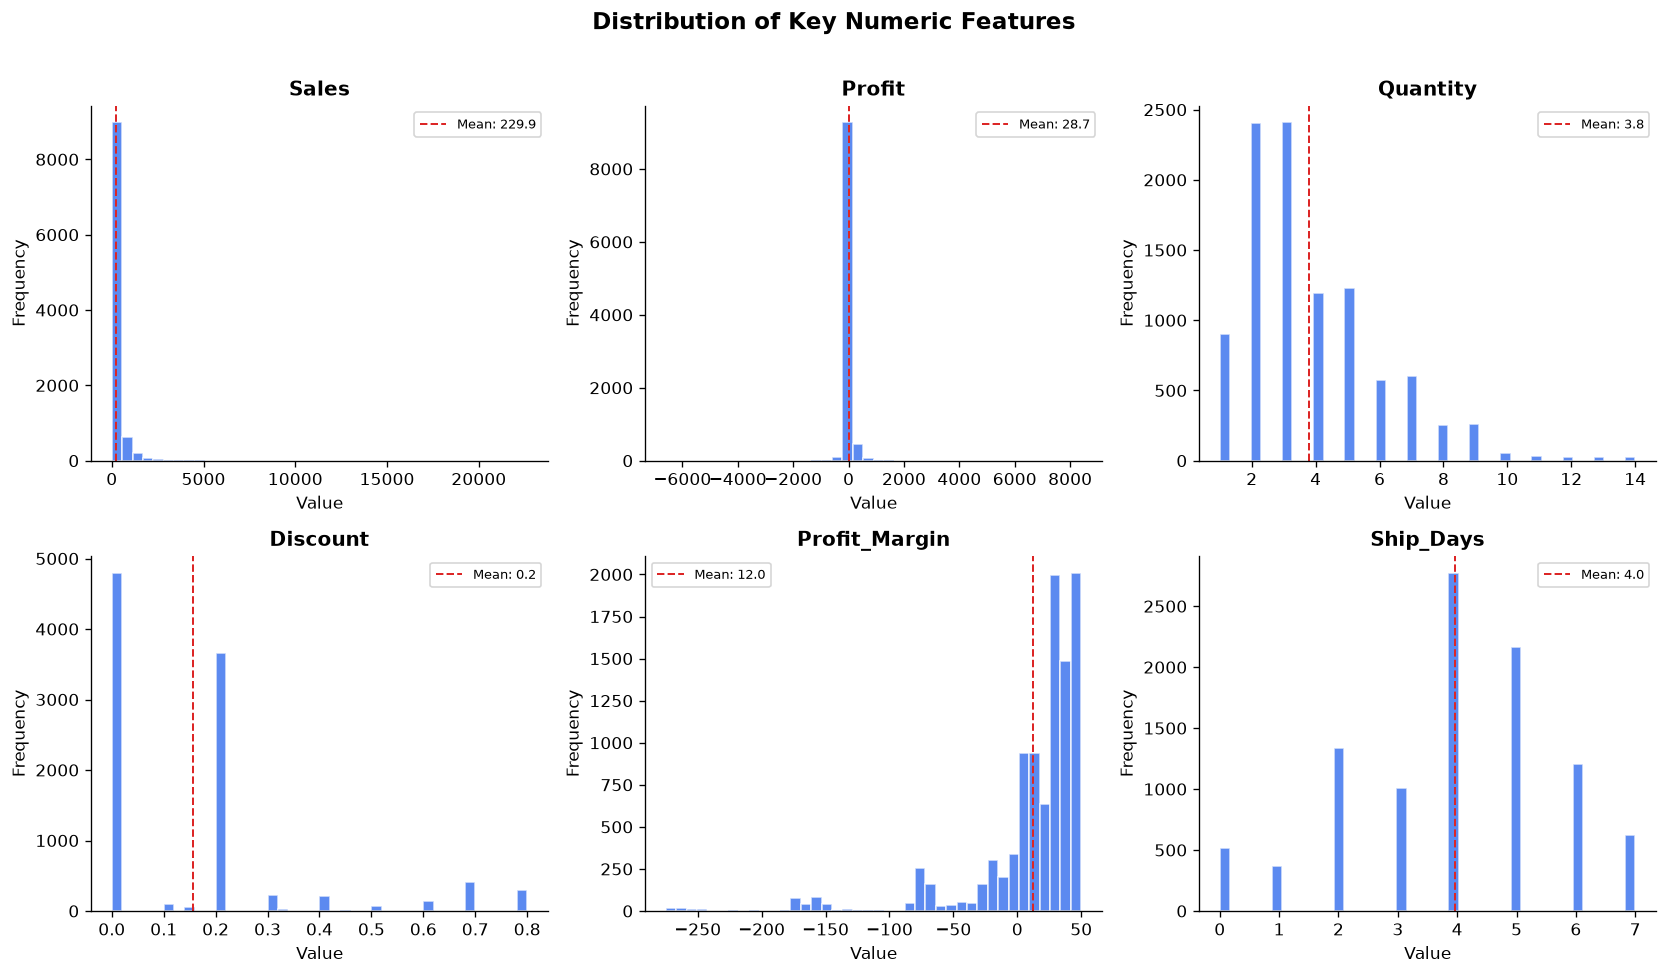

In [16]:
# Distributions of numeric features
num_cols = ['Sales', 'Profit', 'Quantity', 'Discount', 'Profit_Margin', 'Ship_Days']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=40, color=COLORS['primary'], alpha=0.75, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    mean_val = data.mean()
    ax.axvline(mean_val, color=COLORS['loss'], linestyle='--', linewidth=1.2,
               label=f'Mean: {mean_val:.1f}')
    ax.legend(fontsize=8)

fig.suptitle('Distribution of Key Numeric Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

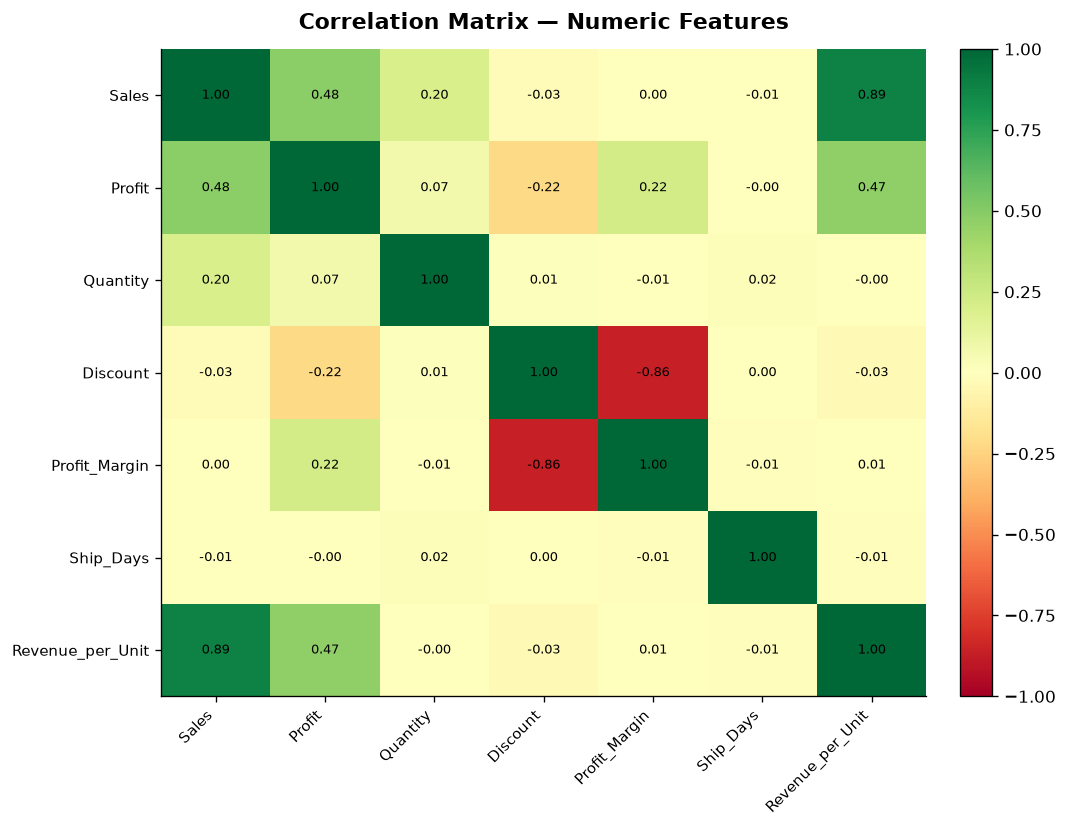

In [17]:
# Correlation matrix
corr_cols = ['Sales','Profit','Quantity','Discount','Profit_Margin','Ship_Days','Revenue_per_Unit']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr.values[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='black')

ax.set_title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

---
## Section 11 — KPI Analysis

In [18]:
total_revenue      = df['Sales'].sum()
total_profit       = df['Profit'].sum()
overall_margin     = (total_profit / total_revenue * 100)
total_orders       = df['Order ID'].nunique()
total_customers    = df['Customer ID'].nunique()
total_products     = df['Product ID'].nunique()
avg_order_value    = df.groupby('Order ID')['Sales'].sum().mean()
avg_profit_order   = df.groupby('Order ID')['Profit'].sum().mean()
loss_txn_count     = df['Is_Loss'].sum()
loss_txn_pct       = loss_txn_count / len(df) * 100

kpis = [
    ('Total Revenue',          f'${total_revenue:,.2f}'),
    ('Total Profit',           f'${total_profit:,.2f}'),
    ('Overall Profit Margin',  f'{overall_margin:.2f}%'),
    ('Total Orders',           f'{total_orders:,}'),
    ('Total Customers',        f'{total_customers:,}'),
    ('Total Products',         f'{total_products:,}'),
    ('Avg Order Value',        f'${avg_order_value:,.2f}'),
    ('Avg Profit per Order',   f'${avg_profit_order:,.2f}'),
    ('Loss Transactions',      f'{loss_txn_count:,}  ({loss_txn_pct:.1f}%)'),
]

print('=' * 50)
print('         KEY PERFORMANCE INDICATORS')
print('=' * 50)
for label, value in kpis:
    print(f'  {label:<28} {value}')
print('=' * 50)

         KEY PERFORMANCE INDICATORS
  Total Revenue                $2,297,200.86
  Total Profit                 $286,397.02
  Overall Profit Margin        12.47%
  Total Orders                 5,009
  Total Customers              793
  Total Products               1,862
  Avg Order Value              $458.61
  Avg Profit per Order         $57.18
  Loss Transactions            1,871  (18.7%)


---
## Section 12 — Sales Analysis

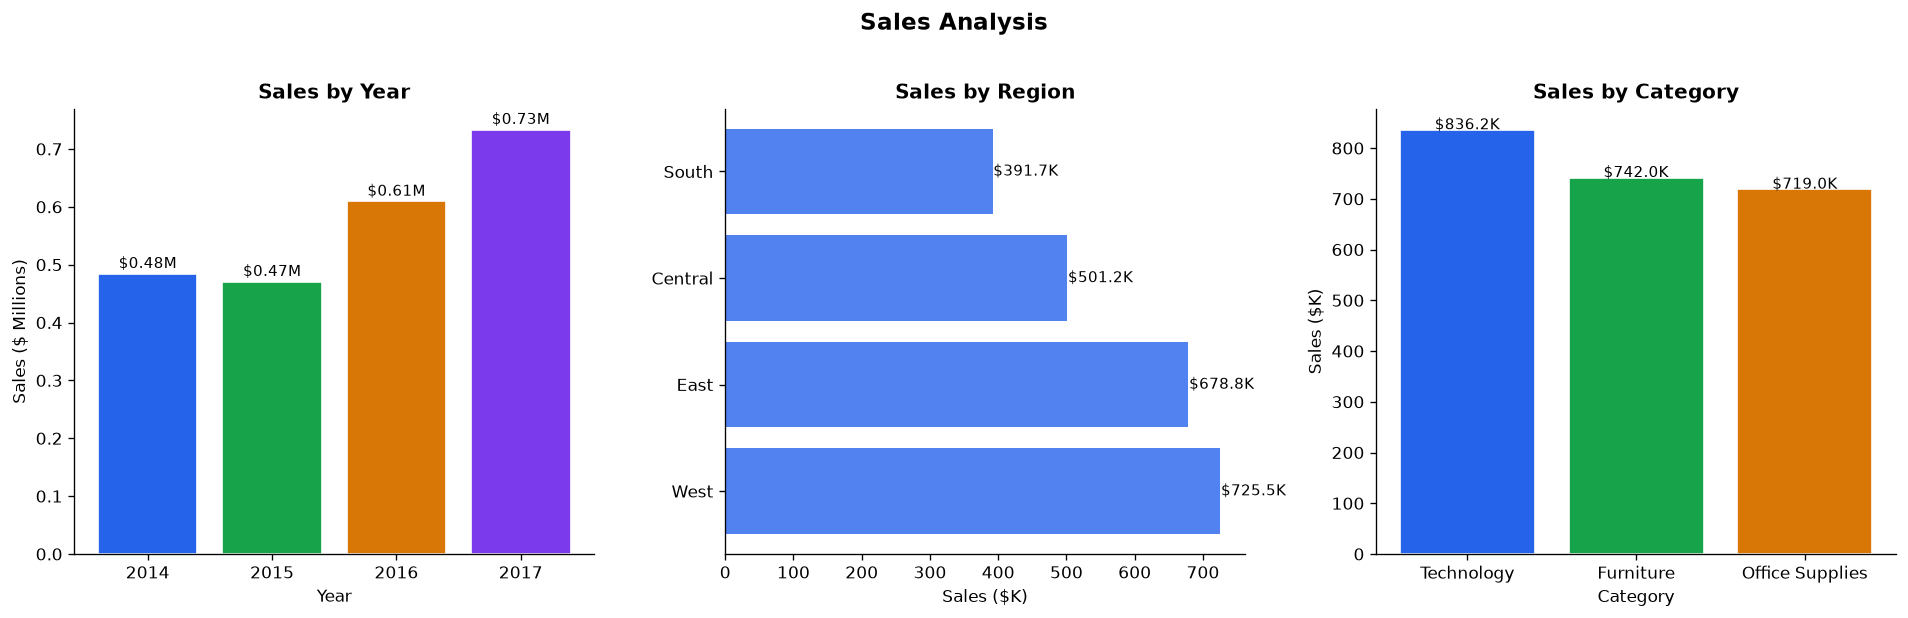


Total Sales: $2,297,200.86


In [19]:
# Sales by Year
sales_by_year = df.groupby('Order_Year')['Sales'].sum().reset_index()

# Sales by Region
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

# Sales by Category
sales_by_cat = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Year ---
axes[0].bar(sales_by_year['Order_Year'].astype(str),
            sales_by_year['Sales'] / 1e6,
            color=COLORS['palette'][:len(sales_by_year)], edgecolor='white')
axes[0].set_title('Sales by Year', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Sales ($ Millions)')
for i, v in enumerate(sales_by_year['Sales']):
    axes[0].text(i, v/1e6 + 0.01, f'${v/1e6:.2f}M', ha='center', fontsize=9)

# --- Region ---
axes[1].barh(sales_by_region.index, sales_by_region.values / 1e3,
             color=COLORS['primary'], alpha=0.8)
axes[1].set_title('Sales by Region', fontweight='bold')
axes[1].set_xlabel('Sales ($K)')
for i, v in enumerate(sales_by_region.values):
    axes[1].text(v/1e3 + 1, i, f'${v/1e3:.1f}K', va='center', fontsize=9)

# --- Category ---
axes[2].bar(sales_by_cat.index, sales_by_cat.values / 1e3,
            color=COLORS['palette'][:3], edgecolor='white')
axes[2].set_title('Sales by Category', fontweight='bold')
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Sales ($K)')
for i, v in enumerate(sales_by_cat.values):
    axes[2].text(i, v/1e3 + 1, f'${v/1e3:.1f}K', ha='center', fontsize=9)

fig.suptitle('Sales Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\nTotal Sales: ${total_revenue:,.2f}')

---
## Section 13 — Profit Analysis

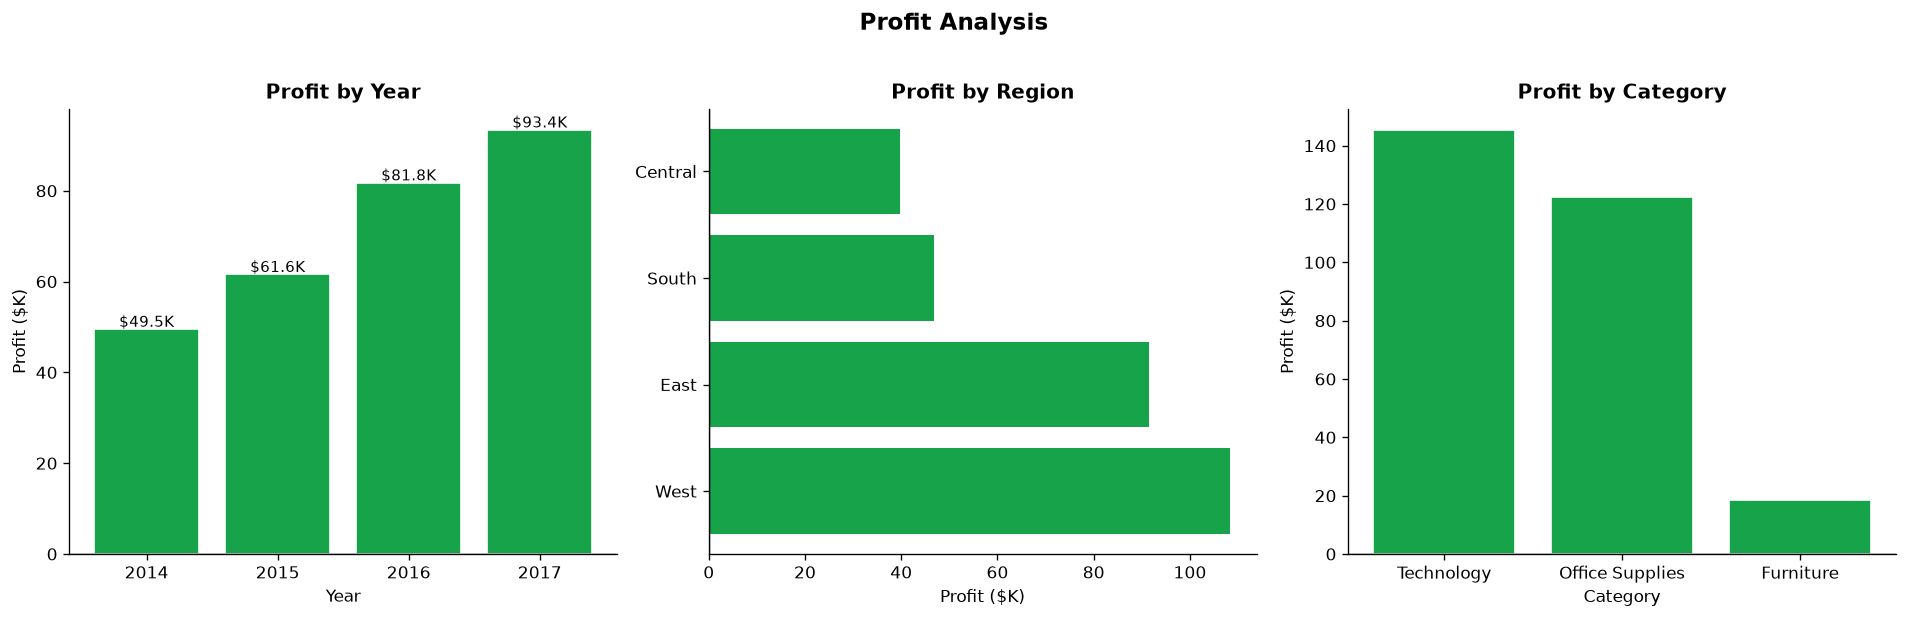

In [20]:
profit_by_year   = df.groupby('Order_Year')['Profit'].sum()
profit_by_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
profit_by_cat    = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Year ---
bar_colors = [COLORS['profit'] if v >= 0 else COLORS['loss']
              for v in profit_by_year.values]
axes[0].bar(profit_by_year.index.astype(str), profit_by_year.values / 1e3,
            color=bar_colors, edgecolor='white')
axes[0].set_title('Profit by Year', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Profit ($K)')
axes[0].axhline(0, color='black', linewidth=0.8)
for i, v in enumerate(profit_by_year.values):
    axes[0].text(i, v/1e3 + 0.5, f'${v/1e3:.1f}K', ha='center', fontsize=9)

# --- Region ---
colors_r = [COLORS['profit'] if v >= 0 else COLORS['loss'] for v in profit_by_region.values]
axes[1].barh(profit_by_region.index, profit_by_region.values / 1e3, color=colors_r)
axes[1].set_title('Profit by Region', fontweight='bold')
axes[1].set_xlabel('Profit ($K)')
axes[1].axvline(0, color='black', linewidth=0.8)

# --- Category ---
colors_c = [COLORS['profit'] if v >= 0 else COLORS['loss'] for v in profit_by_cat.values]
axes[2].bar(profit_by_cat.index, profit_by_cat.values / 1e3, color=colors_c, edgecolor='white')
axes[2].set_title('Profit by Category', fontweight='bold')
axes[2].set_xlabel('Category')
axes[2].set_ylabel('Profit ($K)')
axes[2].axhline(0, color='black', linewidth=0.8)

fig.suptitle('Profit Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Section 14 — Profit Margin Analysis

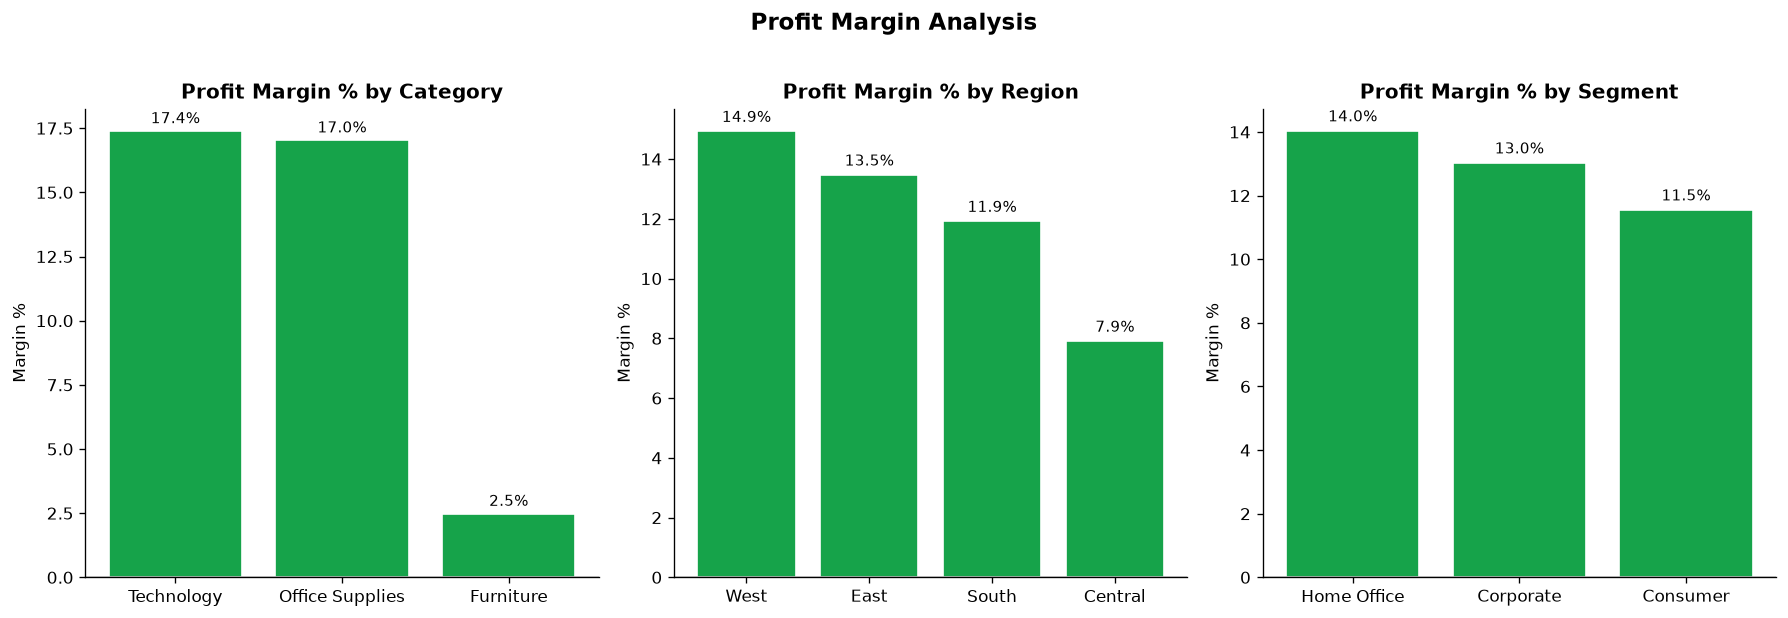

Overall Profit Margin: 12.47%


In [21]:
margin_by_cat    = df.groupby('Category').apply(
    lambda x: x['Profit'].sum() / x['Sales'].sum() * 100).sort_values(ascending=False)
margin_by_region = df.groupby('Region').apply(
    lambda x: x['Profit'].sum() / x['Sales'].sum() * 100).sort_values(ascending=False)
margin_by_seg    = df.groupby('Segment').apply(
    lambda x: x['Profit'].sum() / x['Sales'].sum() * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, data, title in zip(
        axes,
        [margin_by_cat, margin_by_region, margin_by_seg],
        ['Profit Margin % by Category', 'Profit Margin % by Region', 'Profit Margin % by Segment']):
    colors = [COLORS['profit'] if v >= 0 else COLORS['loss'] for v in data.values]
    ax.bar(data.index, data.values, color=colors, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Margin %')
    ax.axhline(0, color='black', linewidth=0.8)
    for i, v in enumerate(data.values):
        ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

fig.suptitle('Profit Margin Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Overall Profit Margin: {overall_margin:.2f}%')

---
## Section 15 — Category Analysis

=== Category Summary ===
                 Total_Sales  Total_Profit  Total_Orders  Total_Qty  Avg_Discount  Profit_Margin_%
Category                                                                                          
Furniture          741999.80      18451.27          1764       8028          0.17             2.49
Office Supplies    719047.03     122490.80          3742      22906          0.16            17.04
Technology         836154.03     145454.95          1544       6939          0.13            17.40


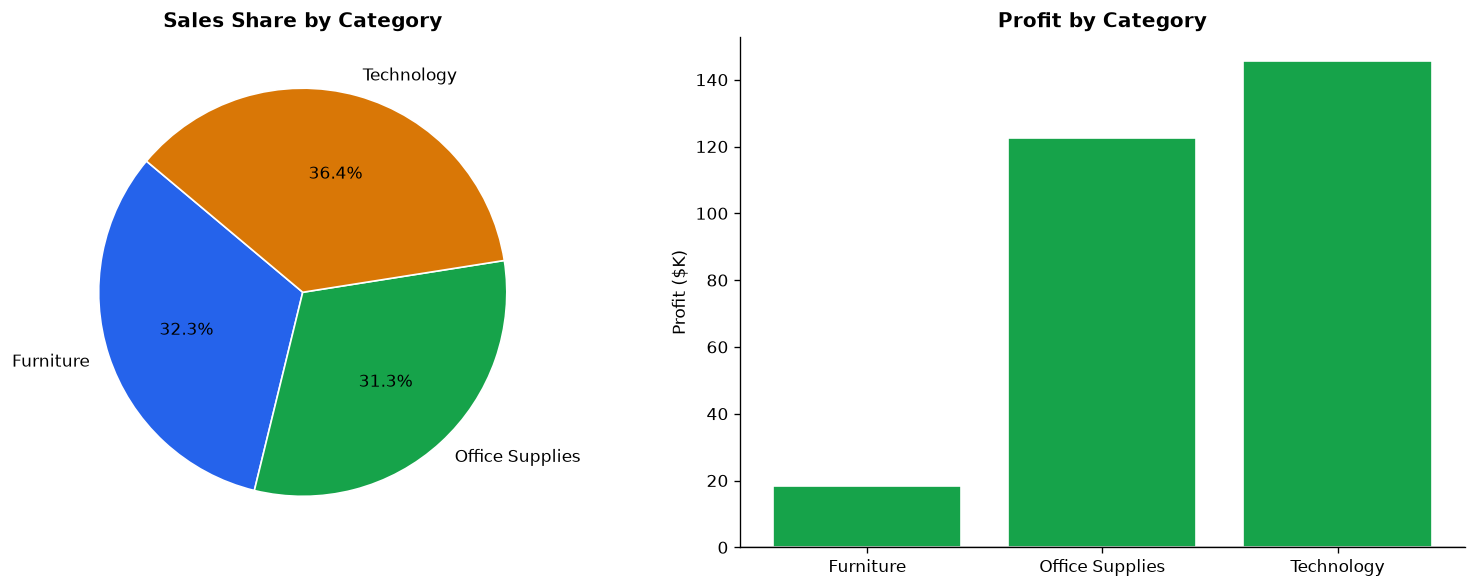

In [22]:
cat_summary = df.groupby('Category').agg(
    Total_Sales    = ('Sales',    'sum'),
    Total_Profit   = ('Profit',   'sum'),
    Total_Orders   = ('Order ID', 'nunique'),
    Total_Qty      = ('Quantity', 'sum'),
    Avg_Discount   = ('Discount', 'mean'),
).round(2)
cat_summary['Profit_Margin_%'] = (cat_summary['Total_Profit'] / cat_summary['Total_Sales'] * 100).round(2)

print('=== Category Summary ===')
print(cat_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sales pie
axes[0].pie(cat_summary['Total_Sales'], labels=cat_summary.index,
            autopct='%1.1f%%', colors=COLORS['palette'][:3],
            startangle=140, wedgeprops={'edgecolor':'white'})
axes[0].set_title('Sales Share by Category', fontweight='bold')

# Profit bar
colors_c = [COLORS['profit'] if v >= 0 else COLORS['loss']
            for v in cat_summary['Total_Profit']]
axes[1].bar(cat_summary.index, cat_summary['Total_Profit'] / 1e3,
            color=colors_c, edgecolor='white')
axes[1].set_title('Profit by Category', fontweight='bold')
axes[1].set_ylabel('Profit ($K)')
axes[1].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

---
## Section 16 — Sub-Category Analysis

=== Sub-Category Summary ===
              Total_Sales  Total_Profit  Quantity  Margin_%
Sub-Category                                               
Phones          330007.05      44515.73      3289     13.49
Chairs          328449.10      26590.17      2356      8.10
Storage         223843.61      21278.83      3158      9.51
Tables          206965.53     -17725.48      1241     -8.56
Binders         203412.73      30221.76      5974     14.86
Machines        189238.63       3384.76       440      1.79
Accessories     167380.32      41936.64      2976     25.05
Copiers         149528.03      55617.82       234     37.20
Bookcases       114880.00      -3472.56       868     -3.02
Appliances      107532.16      18138.01      1729     16.87
Furnishings      91705.16      13059.14      3563     14.24
Paper            78479.21      34053.57      5178     43.39
Supplies         46673.54      -1189.10       647     -2.55
Art              27118.79       6527.79      3000     24.07
Envelopes  

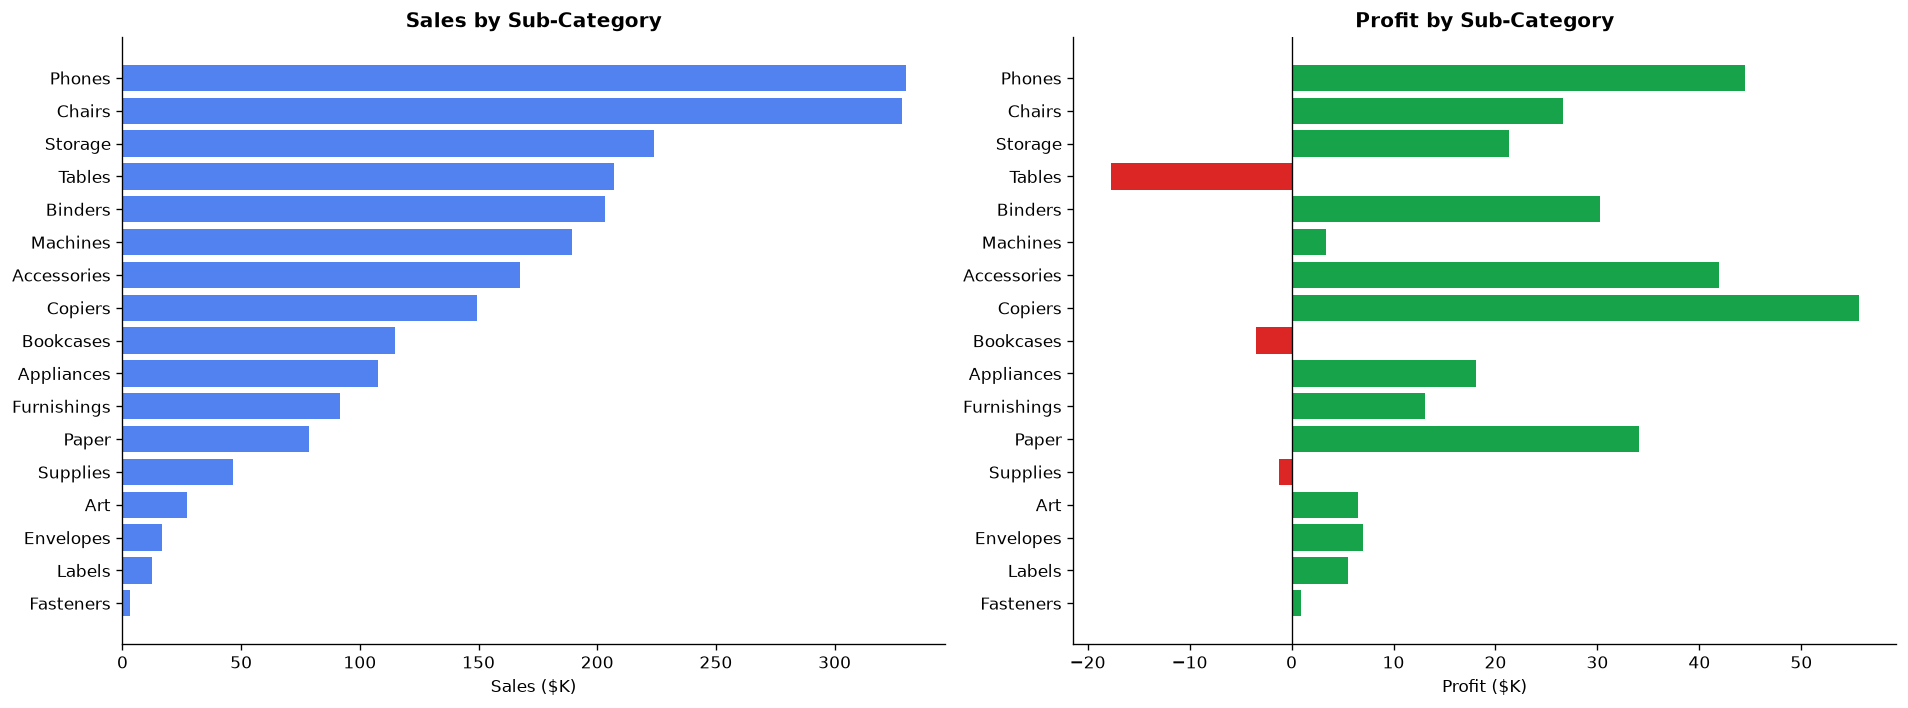

In [23]:
subcat = df.groupby('Sub-Category').agg(
    Total_Sales  = ('Sales',  'sum'),
    Total_Profit = ('Profit', 'sum'),
    Quantity     = ('Quantity','sum')
).sort_values('Total_Sales', ascending=False).round(2)
subcat['Margin_%'] = (subcat['Total_Profit'] / subcat['Total_Sales'] * 100).round(2)

print('=== Sub-Category Summary ===')
print(subcat.to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sales
axes[0].barh(subcat.index, subcat['Total_Sales'] / 1e3,
             color=COLORS['primary'], alpha=0.8)
axes[0].set_title('Sales by Sub-Category', fontweight='bold')
axes[0].set_xlabel('Sales ($K)')
axes[0].invert_yaxis()

# Profit — color coded
colors_s = [COLORS['profit'] if v >= 0 else COLORS['loss']
            for v in subcat['Total_Profit']]
axes[1].barh(subcat.index, subcat['Total_Profit'] / 1e3, color=colors_s)
axes[1].set_title('Profit by Sub-Category', fontweight='bold')
axes[1].set_xlabel('Profit ($K)')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

---
## Section 17 — Regional Analysis

=== Regional Summary ===
         Total_Sales  Total_Profit  Total_Orders  Avg_Discount  Margin_%
Region                                                                  
Central    501239.89      39706.36          1175          0.24      7.92
East       678781.24      91522.78          1401          0.15     13.48
South      391721.90      46749.43           822          0.15     11.93
West       725457.82     108418.45          1611          0.11     14.94


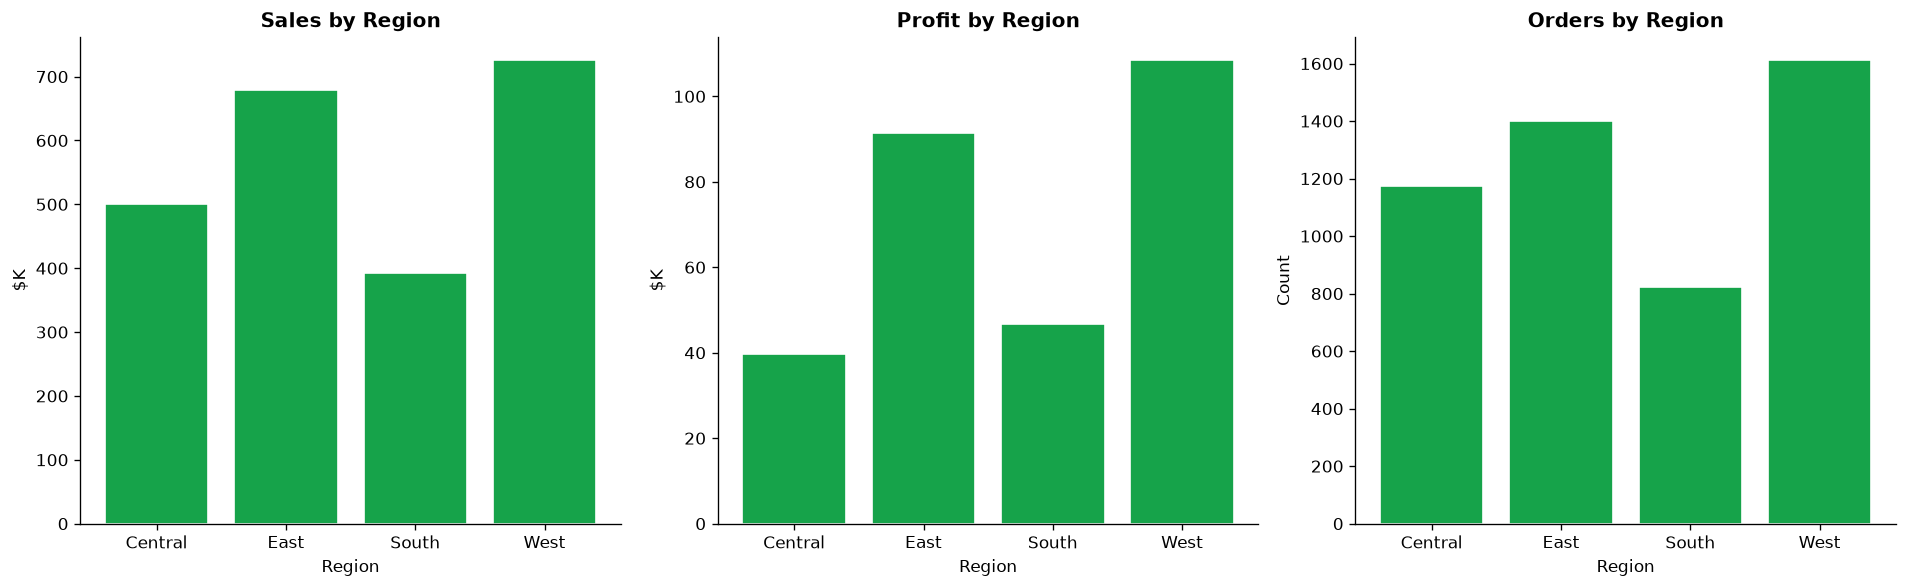

In [24]:
region_summary = df.groupby('Region').agg(
    Total_Sales    = ('Sales',    'sum'),
    Total_Profit   = ('Profit',   'sum'),
    Total_Orders   = ('Order ID', 'nunique'),
    Avg_Discount   = ('Discount', 'mean'),
).round(2)
region_summary['Margin_%'] = (region_summary['Total_Profit']
                              / region_summary['Total_Sales'] * 100).round(2)

print('=== Regional Summary ===')
print(region_summary.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['Total_Sales', 'Total_Profit', 'Total_Orders']
titles  = ['Sales by Region', 'Profit by Region', 'Orders by Region']
for ax, m, t in zip(axes, metrics, titles):
    vals   = region_summary[m]
    colors = [COLORS['profit'] if v >= 0 else COLORS['loss'] for v in vals]
    ax.bar(region_summary.index, vals / 1e3 if 'Orders' not in t else vals,
           color=colors, edgecolor='white')
    ax.set_title(t, fontweight='bold')
    ax.set_xlabel('Region')
    ax.set_ylabel('$K' if 'Orders' not in t else 'Count')

plt.tight_layout()
plt.show()

---
## Section 18 — Customer Analysis

=== Customer Statistics ===
Total Customers        : 793
Avg Revenue/Customer   : $2,896.85
Avg Profit/Customer    : $361.16
Avg Orders/Customer    : 6.3


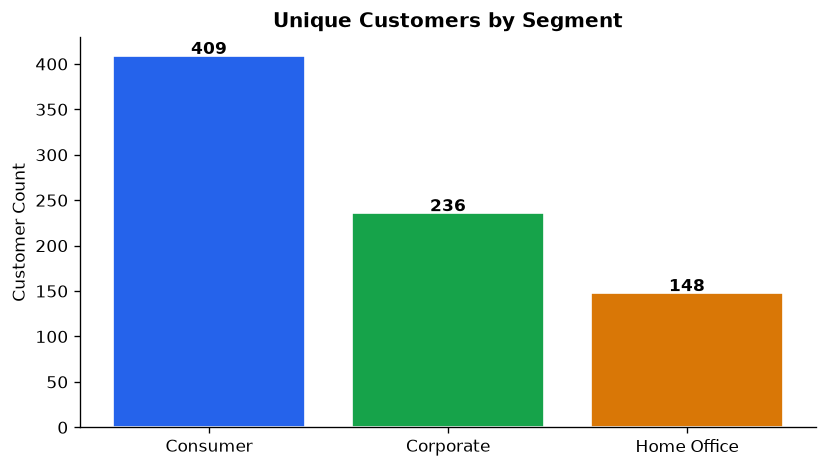

In [26]:
cust_summary = df.groupby(['Customer ID','Customer Name']).agg(
    Total_Sales    = ('Sales',    'sum'),
    Total_Profit   = ('Profit',   'sum'),
    Total_Orders   = ('Order ID', 'nunique'),
    Avg_Discount   = ('Discount', 'mean'),
).round(2).reset_index()

print('=== Customer Statistics ===')
print(f'Total Customers        : {len(cust_summary):,}')
print(f'Avg Revenue/Customer   : ${cust_summary["Total_Sales"].mean():,.2f}')
print(f'Avg Profit/Customer    : ${cust_summary["Total_Profit"].mean():,.2f}')
print(f'Avg Orders/Customer    : {cust_summary["Total_Orders"].mean():.1f}')

# Segments
seg_cust = df.groupby('Segment')['Customer ID'].nunique()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(seg_cust.index, seg_cust.values,
       color=COLORS['palette'][:3], edgecolor='white')
ax.set_title('Unique Customers by Segment', fontweight='bold')
ax.set_ylabel('Customer Count')
for i, v in enumerate(seg_cust.values):
    ax.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 19 — Product Analysis

In [25]:
prod_summary = df.groupby(['Product ID','Product Name']).agg(
    Total_Sales  = ('Sales',    'sum'),
    Total_Profit = ('Profit',   'sum'),
    Qty_Sold     = ('Quantity', 'sum'),
).round(2).reset_index()
prod_summary['Margin_%'] = (prod_summary['Total_Profit']
                            / prod_summary['Total_Sales'] * 100).round(2)

print(f'Unique Products       : {len(prod_summary):,}')
print(f'Avg Revenue/Product   : ${prod_summary["Total_Sales"].mean():,.2f}')
print(f'\nTop 5 Products by Sales:')
print(prod_summary.nlargest(5, 'Total_Sales')[['Product Name','Total_Sales','Total_Profit']]
      .to_string(index=False))

print(f'\nBottom 5 Products by Profit (most loss-making):')
print(prod_summary.nsmallest(5, 'Total_Profit')[['Product Name','Total_Sales','Total_Profit']]
      .to_string(index=False))

Unique Products       : 1,894
Avg Revenue/Product   : $1,212.88

Top 5 Products by Sales:
                                                               Product Name  Total_Sales  Total_Profit
                                      Canon imageCLASS 2200 Advanced Copier     61599.82      25199.93
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     27453.38       7753.04
                      Cisco TelePresence System EX90 Videoconferencing Unit     22638.48      -1811.08
                               HON 5400 Series Task Chairs for Big and Tall     21870.58          0.00
                                 GBC DocuBind TL300 Electric Binding System     19823.48       2233.51

Bottom 5 Products by Profit (most loss-making):
                                            Product Name  Total_Sales  Total_Profit
               Cubify CubeX 3D Printer Double Head Print     11099.96      -8879.97
               Lexmark MX611dhe Monochrome Laser Printer     16829.90      

---
## Section 20 — Segment Analysis

=== Segment Summary ===
             Total_Sales  Total_Profit  Total_Orders  Avg_Discount  Margin_%
Segment                                                                     
Consumer      1161401.34     134119.21          2586          0.16     11.55
Corporate      706146.37      91979.13          1514          0.16     13.03
Home Office    429653.15      60298.68           909          0.15     14.03


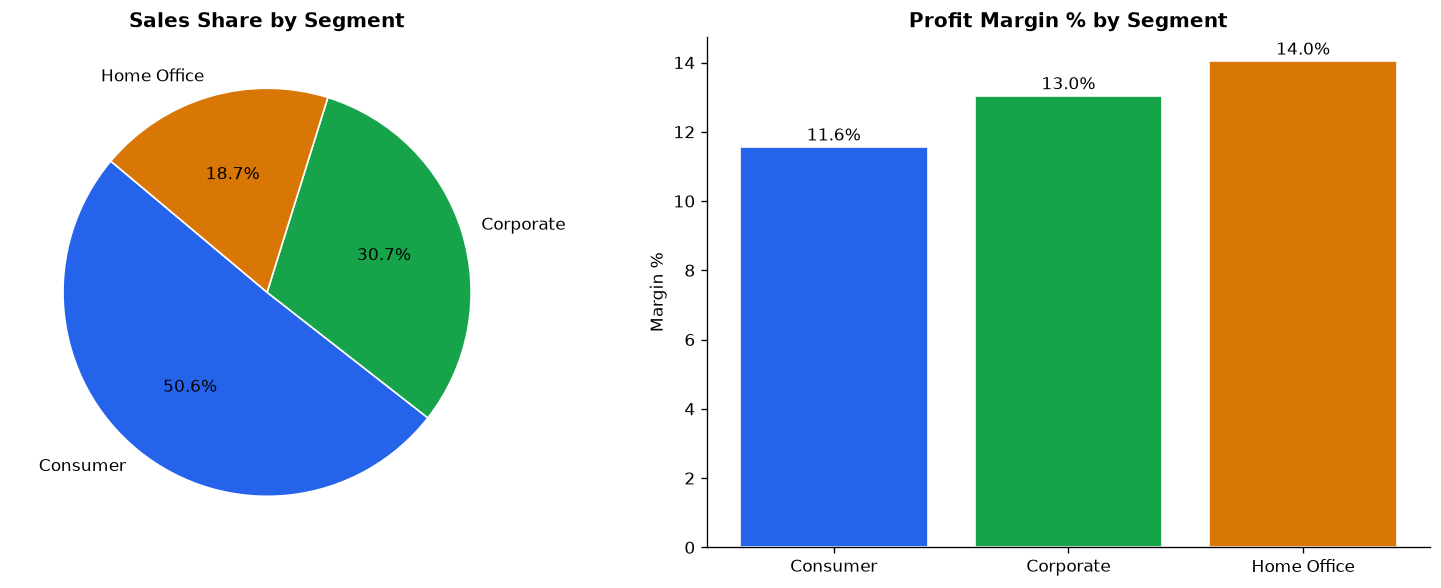

In [27]:
seg_summary = df.groupby('Segment').agg(
    Total_Sales  = ('Sales',    'sum'),
    Total_Profit = ('Profit',   'sum'),
    Total_Orders = ('Order ID', 'nunique'),
    Avg_Discount = ('Discount', 'mean'),
).round(2)
seg_summary['Margin_%'] = (seg_summary['Total_Profit']
                           / seg_summary['Total_Sales'] * 100).round(2)

print('=== Segment Summary ===')
print(seg_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(seg_summary['Total_Sales'], labels=seg_summary.index,
            autopct='%1.1f%%', colors=COLORS['palette'][:3],
            startangle=140, wedgeprops={'edgecolor':'white'})
axes[0].set_title('Sales Share by Segment', fontweight='bold')

axes[1].bar(seg_summary.index, seg_summary['Margin_%'],
            color=COLORS['palette'][:3], edgecolor='white')
axes[1].set_title('Profit Margin % by Segment', fontweight='bold')
axes[1].set_ylabel('Margin %')
for i, v in enumerate(seg_summary['Margin_%']):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## Section 21 — Monthly Sales Trend

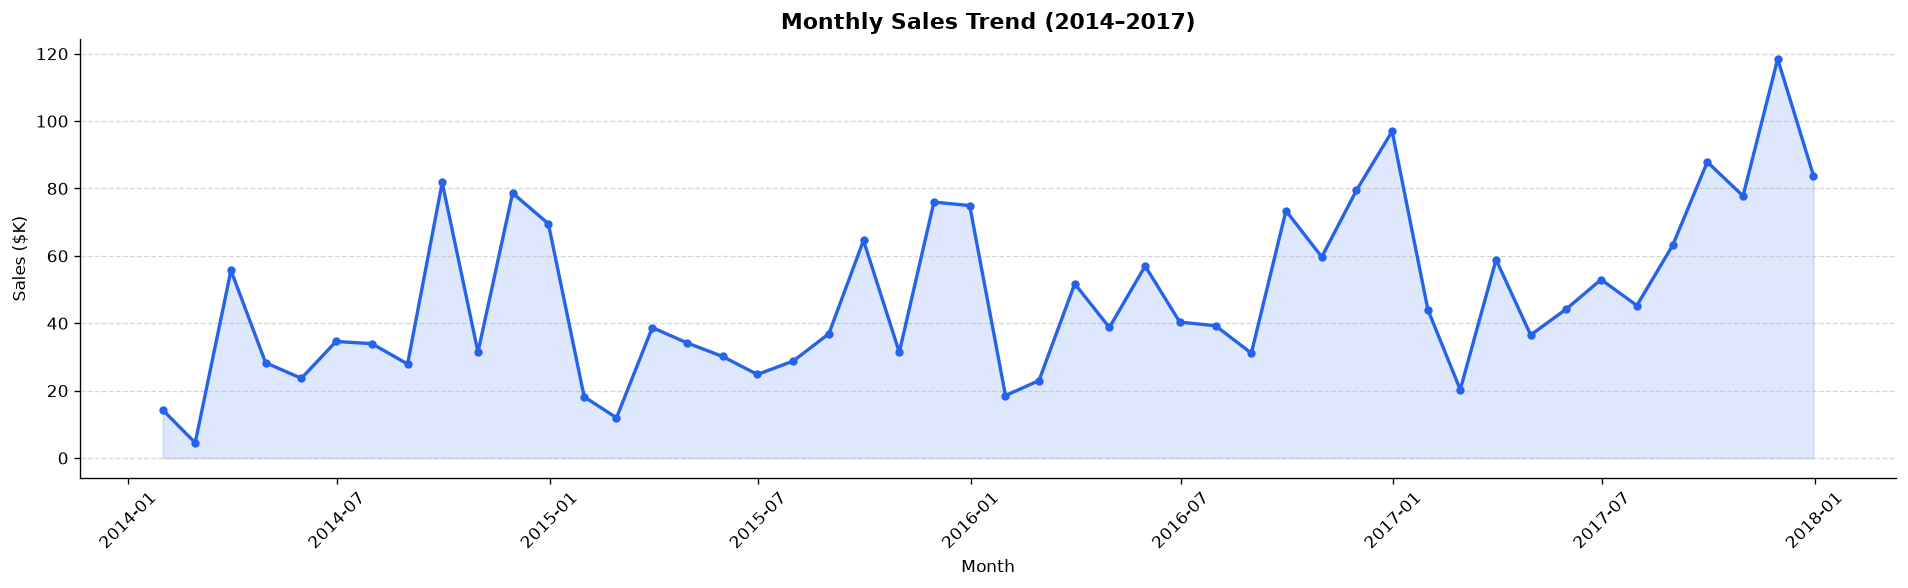

Peak sales month : Nov 2017
Peak sales value : $118,447.82


In [38]:
monthly_sales = (df.set_index('Order Date')
                   .resample('ME')['Sales']
                   .sum()
                   .reset_index())
monthly_sales.columns = ['Month','Sales']

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly_sales['Month'], monthly_sales['Sales'] / 1e3,
        color=COLORS['primary'], linewidth=2, marker='o', markersize=4)
ax.fill_between(monthly_sales['Month'], monthly_sales['Sales'] / 1e3,
                alpha=0.15, color=COLORS['primary'])
ax.set_title('Monthly Sales Trend (2014–2017)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Sales ($K)')
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(f'Peak sales month : {monthly_sales.loc[monthly_sales["Sales"].idxmax(), "Month"].strftime("%b %Y")}')
print(f'Peak sales value : ${monthly_sales["Sales"].max():,.2f}')

---
## Section 22 — Monthly Profit Trend

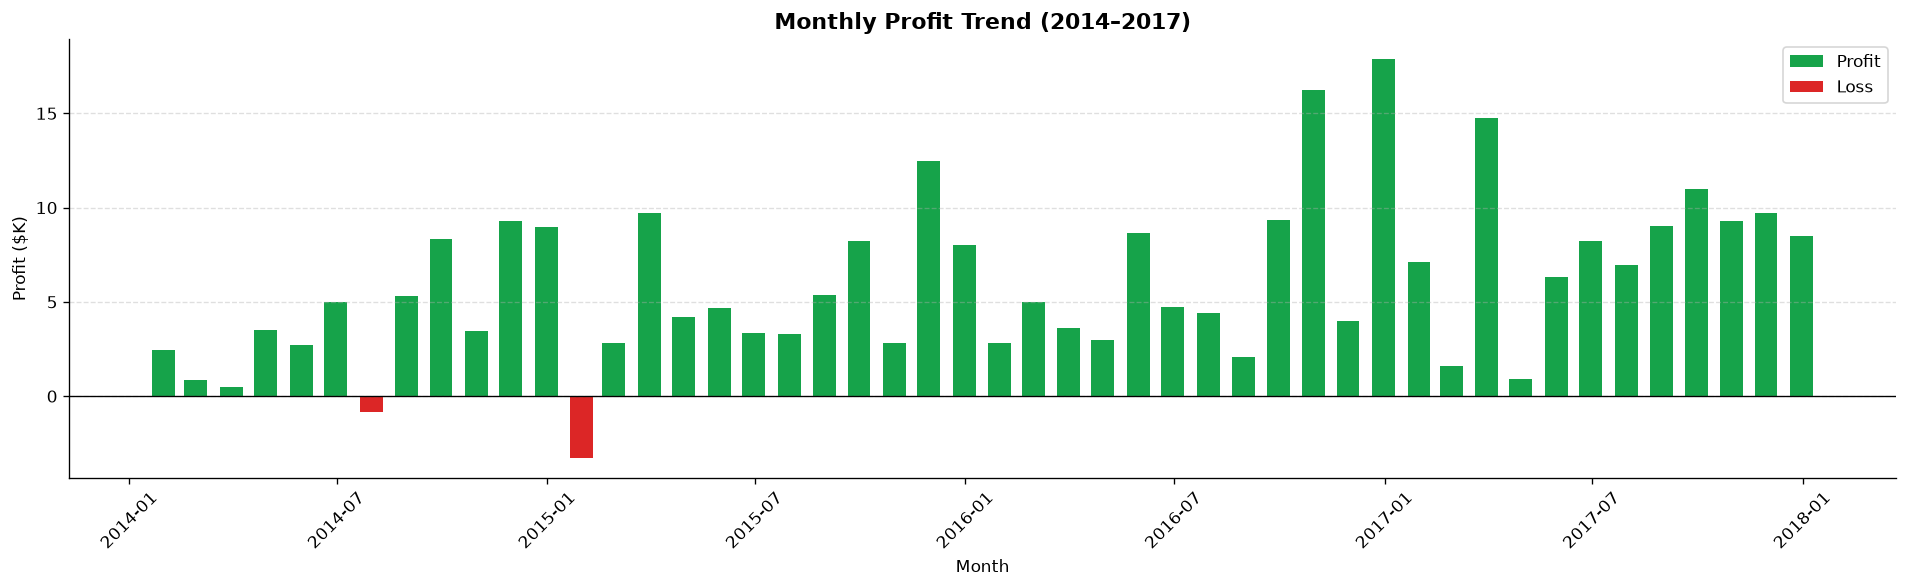

In [39]:
monthly_profit = (df.set_index('Order Date')
                    .resample('ME')['Profit']
                    .sum()
                    .reset_index())
monthly_profit.columns = ['Month','Profit']

fig, ax = plt.subplots(figsize=(16, 5))
colors_m = [COLORS['profit'] if v >= 0 else COLORS['loss']
            for v in monthly_profit['Profit']]
ax.bar(monthly_profit['Month'], monthly_profit['Profit'] / 1e3,
       color=colors_m, width=20)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Monthly Profit Trend (2014–2017)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Profit ($K)')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.tick_params(axis='x', rotation=45)
legend_elements = [Patch(facecolor=COLORS['profit'], label='Profit'),
                   Patch(facecolor=COLORS['loss'],   label='Loss')]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

---
## Section 23 — Discount vs Profit Analysis

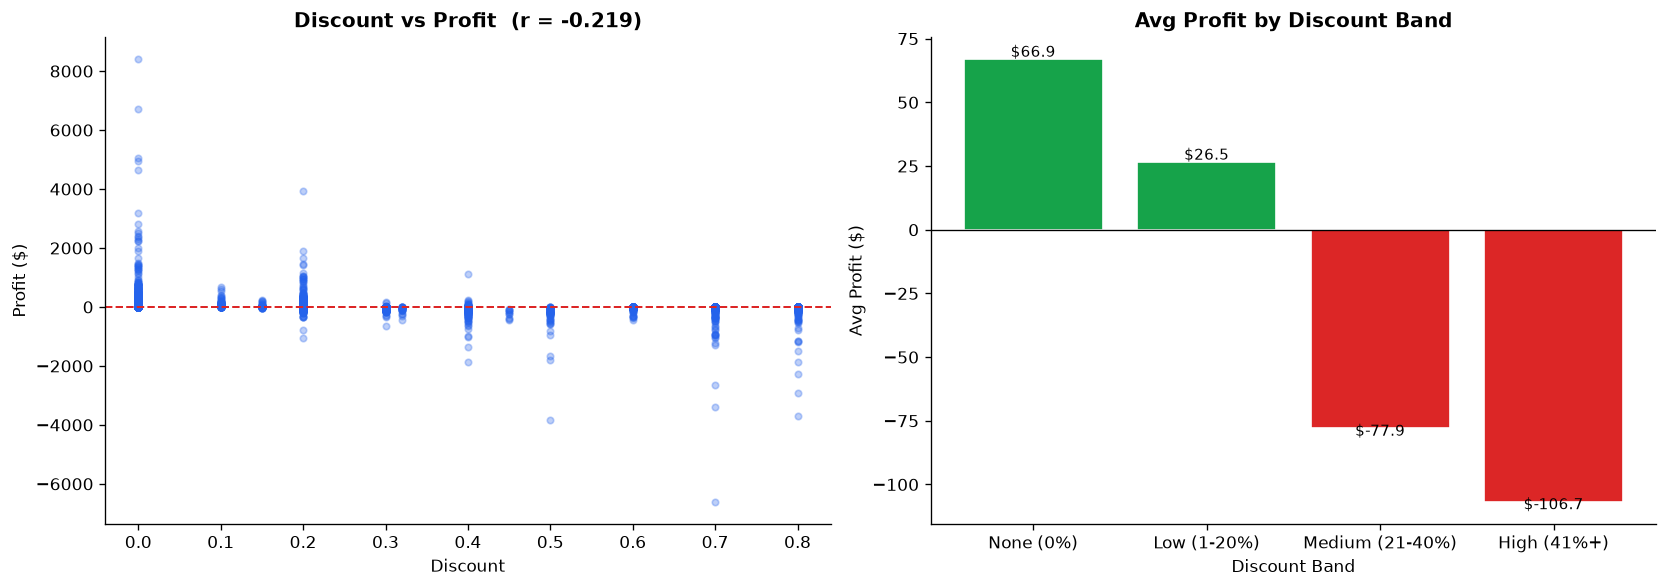

Pearson Correlation (Discount vs Profit): -0.2195
Strong negative correlation: higher discounts drive lower/negative profit.


In [30]:
corr_disc_profit = df['Discount'].corr(df['Profit'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter
axes[0].scatter(df['Discount'], df['Profit'], alpha=0.3, s=15, color=COLORS['primary'])
axes[0].axhline(0, color=COLORS['loss'], linewidth=1.2, linestyle='--')
axes[0].set_title(f'Discount vs Profit  (r = {corr_disc_profit:.3f})', fontweight='bold')
axes[0].set_xlabel('Discount')
axes[0].set_ylabel('Profit ($)')

# Grouped by discount band
band_profit = df.groupby('Discount_Band')['Profit'].mean()
colors_b = [COLORS['profit'] if v >= 0 else COLORS['loss'] for v in band_profit.values]
axes[1].bar(band_profit.index.astype(str), band_profit.values, color=colors_b, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Avg Profit by Discount Band', fontweight='bold')
axes[1].set_xlabel('Discount Band')
axes[1].set_ylabel('Avg Profit ($)')
for i, v in enumerate(band_profit.values):
    axes[1].text(i, v + (1 if v >= 0 else -3), f'${v:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Pearson Correlation (Discount vs Profit): {corr_disc_profit:.4f}')
print('Strong negative correlation: higher discounts drive lower/negative profit.')

---
## Section 24 — Loss-Making Transactions & Orders

In [31]:
loss_df = df[df['Is_Loss'] == 1].copy()

print('=== Loss-Making Transaction Summary ===')
print(f'Total loss transactions   : {len(loss_df):,}  ({len(loss_df)/len(df)*100:.1f}% of all)')
print(f'Total loss amount         : ${loss_df["Profit"].sum():,.2f}')
print(f'Avg loss per transaction  : ${loss_df["Profit"].mean():,.2f}')
print(f'Worst single transaction  : ${loss_df["Profit"].min():,.2f}')

print('\nLoss transactions by Category:')
print(loss_df.groupby('Category')['Profit'].agg(['count','sum']).rename(
    columns={'count':'Txn Count','sum':'Total Loss'}).to_string())

print('\nLoss transactions by Sub-Category (Top 5):')
print(loss_df.groupby('Sub-Category')['Profit'].sum()
      .sort_values().head(5).to_string())

print('\nTop 10 Worst Individual Transactions:')
worst = loss_df.nsmallest(10, 'Profit')[[
    'Order ID','Product Name','Category','Sales','Discount','Profit']]
print(worst.to_string(index=False))

=== Loss-Making Transaction Summary ===
Total loss transactions   : 1,871  (18.7% of all)
Total loss amount         : $-156,131.29
Avg loss per transaction  : $-83.45
Worst single transaction  : $-6,599.98

Loss transactions by Category:
                 Txn Count  Total Loss
Category                              
Furniture              714   -60936.11
Office Supplies        886   -56615.26
Technology             271   -38579.92

Loss transactions by Sub-Category (Top 5):
Sub-Category
Binders     -38510.50
Tables      -32412.15
Machines    -30118.67
Bookcases   -12152.21
Chairs       -9880.84

Top 10 Worst Individual Transactions:
      Order ID                                                                Product Name        Category    Sales  Discount   Profit
CA-2016-108196                                   Cubify CubeX 3D Printer Double Head Print      Technology  4499.98      0.70 -6599.98
US-2017-168116                                   Cubify CubeX 3D Printer Triple Head Print 

---
## Section 25 — Top Customers

=== Top 10 Customers by Revenue ===
     Customer Name  Total_Sales  Total_Profit  Total_Orders
       Sean Miller     25043.05      -1980.74             5
      Tamara Chand     19052.22       8981.32             5
      Raymond Buch     15117.34       6976.10             6
      Tom Ashbrook     14595.62       4703.79             4
     Adrian Barton     14473.57       5444.81            10
      Ken Lonsdale     14175.23        806.86            12
      Sanjit Chand     14142.33       5757.41             9
      Hunter Lopez     12873.30       5622.43             6
      Sanjit Engle     12209.44       2650.68            11
Christopher Conant     12129.07       2177.05             5

=== Top 10 Customers by Profit ===
       Customer Name  Total_Sales  Total_Profit  Total_Orders
        Tamara Chand     19052.22       8981.32             5
        Raymond Buch     15117.34       6976.10             6
        Sanjit Chand     14142.33       5757.41             9
        Hunter Lopez

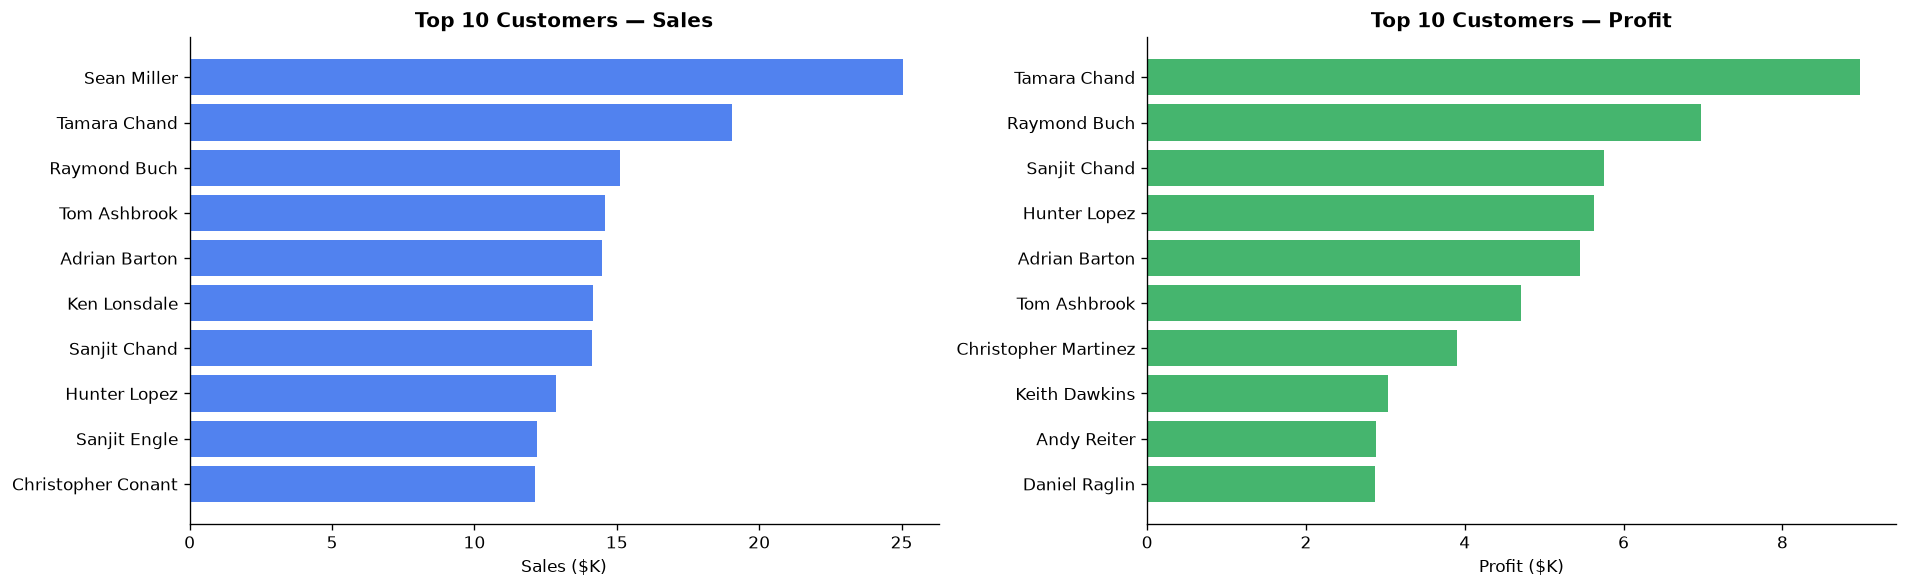

In [32]:
top_cust_sales  = cust_summary.nlargest(10, 'Total_Sales')
top_cust_profit = cust_summary.nlargest(10, 'Total_Profit')

print('=== Top 10 Customers by Revenue ===')
print(top_cust_sales[['Customer Name','Total_Sales','Total_Profit','Total_Orders']]
      .to_string(index=False))

print('\n=== Top 10 Customers by Profit ===')
print(top_cust_profit[['Customer Name','Total_Sales','Total_Profit','Total_Orders']]
      .to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].barh(top_cust_sales['Customer Name'], top_cust_sales['Total_Sales'] / 1e3,
             color=COLORS['primary'], alpha=0.8)
axes[0].set_title('Top 10 Customers — Sales', fontweight='bold')
axes[0].set_xlabel('Sales ($K)')
axes[0].invert_yaxis()

axes[1].barh(top_cust_profit['Customer Name'], top_cust_profit['Total_Profit'] / 1e3,
             color=COLORS['profit'], alpha=0.8)
axes[1].set_title('Top 10 Customers — Profit', fontweight='bold')
axes[1].set_xlabel('Profit ($K)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

---
## Section 26 — Top Products

=== Top 10 Products by Revenue ===
                                                               Product Name  Total_Sales  Total_Profit
                                      Canon imageCLASS 2200 Advanced Copier     61599.82      25199.93
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     27453.38       7753.04
                      Cisco TelePresence System EX90 Videoconferencing Unit     22638.48      -1811.08
                               HON 5400 Series Task Chairs for Big and Tall     21870.58          0.00
                                 GBC DocuBind TL300 Electric Binding System     19823.48       2233.51
                           GBC Ibimaster 500 Manual ProClick Binding System     19024.50        760.98
                                       Hewlett Packard LaserJet 3310 Copier     18839.69       6983.88
                  HP Designjet T520 Inkjet Large Format Printer - 24" Color     18374.90       4094.98
                                  GBC 

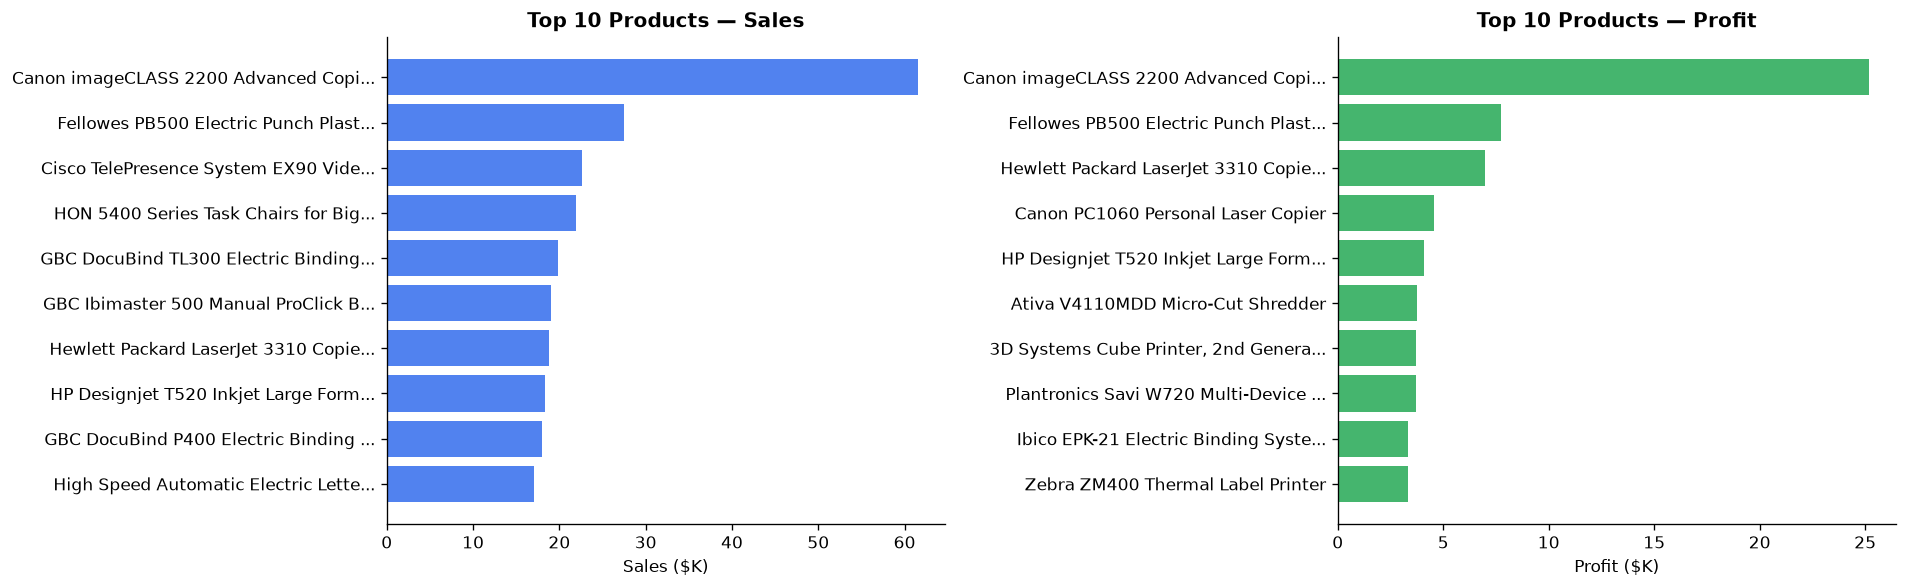

In [33]:
top_prod_sales  = prod_summary.nlargest(10, 'Total_Sales')
top_prod_profit = prod_summary.nlargest(10, 'Total_Profit')

print('=== Top 10 Products by Revenue ===')
print(top_prod_sales[['Product Name','Total_Sales','Total_Profit']].to_string(index=False))

print('\n=== Top 10 Products by Profit ===')
print(top_prod_profit[['Product Name','Total_Sales','Total_Profit']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Truncate long names
def truncate(name, n=35):
    return name[:n] + '...' if len(name) > n else name

axes[0].barh([truncate(n) for n in top_prod_sales['Product Name']],
             top_prod_sales['Total_Sales'] / 1e3,
             color=COLORS['primary'], alpha=0.8)
axes[0].set_title('Top 10 Products — Sales', fontweight='bold')
axes[0].set_xlabel('Sales ($K)')
axes[0].invert_yaxis()

axes[1].barh([truncate(n) for n in top_prod_profit['Product Name']],
             top_prod_profit['Total_Profit'] / 1e3,
             color=COLORS['profit'], alpha=0.8)
axes[1].set_title('Top 10 Products — Profit', fontweight='bold')
axes[1].set_xlabel('Profit ($K)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

---
## Section 27 — AI Anomaly Detection — Isolation Forest

In [34]:
print('=' * 60)
print('  AI-ASSISTED TRANSACTION ANOMALY DETECTION')
print('  Algorithm : Isolation Forest (Unsupervised)')
print('  Features  : Sales, Quantity, Discount, Profit')
print('  Contamination : 5%  |  random_state : 42')
print('=' * 60)

# Feature matrix
features = ['Sales', 'Quantity', 'Discount', 'Profit']
X = df[features].copy()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit Isolation Forest
iso = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_scaled)

# Predict
df['Anomaly_Flag']  = iso.predict(X_scaled)   # -1 = anomaly, 1 = normal
df['Anomaly_Score'] = iso.score_samples(X_scaled)  # lower = more anomalous

n_anomalies = (df['Anomaly_Flag'] == -1).sum()
n_normal    = (df['Anomaly_Flag'] ==  1).sum()

print(f'\nResults:')
print(f'  Normal transactions   : {n_normal:,}  ({n_normal/len(df)*100:.1f}%)')
print(f'  Anomalous transactions: {n_anomalies:,}  ({n_anomalies/len(df)*100:.1f}%)')

anomalies = df[df['Anomaly_Flag'] == -1].copy()

print('\n=== Anomaly Summary Statistics ===')
print(anomalies[['Sales','Quantity','Discount','Profit']].describe().round(2).to_string())

print('\n=== Anomaly Distribution by Category ===')
print(anomalies['Category'].value_counts().to_string())

print('\n=== Anomaly Distribution by Region ===')
print(anomalies['Region'].value_counts().to_string())

  AI-ASSISTED TRANSACTION ANOMALY DETECTION
  Algorithm : Isolation Forest (Unsupervised)
  Features  : Sales, Quantity, Discount, Profit
  Contamination : 5%  |  random_state : 42

Results:
  Normal transactions   : 9,494  (95.0%)
  Anomalous transactions: 500  (5.0%)

=== Anomaly Summary Statistics ===
         Sales  Quantity  Discount   Profit
count   500.00    500.00    500.00   500.00
mean   1722.76      6.58      0.31   161.78
std    2089.12      3.21      0.30  1009.79
min       3.24      1.00      0.00 -6599.98
25%     437.06      4.00      0.00  -250.70
50%    1399.96      6.00      0.20    99.14
75%    2153.31      9.00      0.62   469.40
max   22638.48     14.00      0.80  8399.98

=== Anomaly Distribution by Category ===
Category
Office Supplies    180
Furniture          164
Technology         156

=== Anomaly Distribution by Region ===
Region
Central    151
East       145
West       130
South       74


In [ ]:
print('=== Top 20 Most Anomalous Transactions ===')
top_anomalies = anomalies.nsmallest(20, 'Anomaly_Score')[[
    'Order ID','Category','Sub-Category','Sales','Quantity','Discount','Profit','Anomaly_Score'
]]
print(top_anomalies.to_string(index=False))

---
## Section 28 — Anomaly Visualization

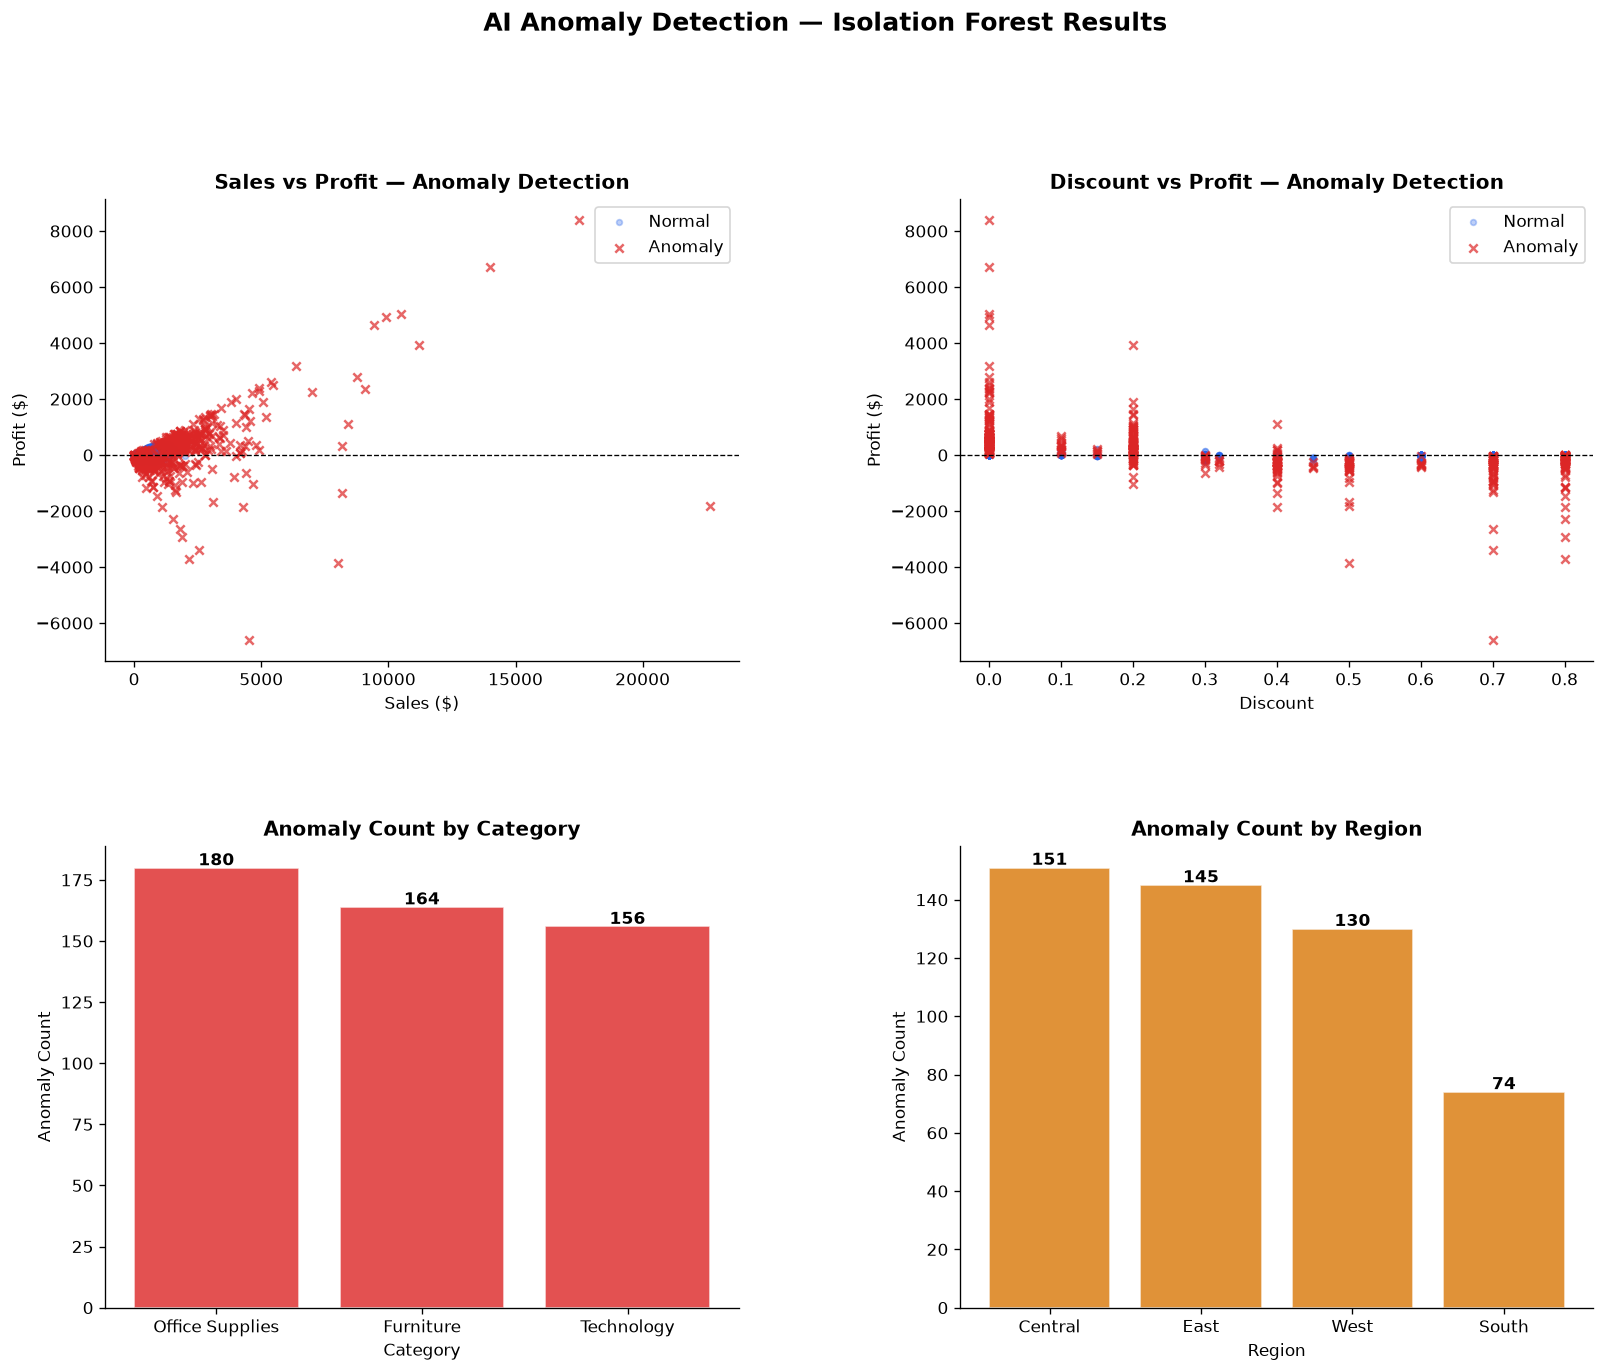

In [35]:
normal_df  = df[df['Anomaly_Flag'] ==  1]
anomaly_df = df[df['Anomaly_Flag'] == -1]

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# --- Plot 1: Sales vs Profit scatter ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(normal_df['Sales'],  normal_df['Profit'],
            alpha=0.3, s=12, color=COLORS['primary'],  label='Normal')
ax1.scatter(anomaly_df['Sales'], anomaly_df['Profit'],
            alpha=0.7, s=25, color=COLORS['loss'],     label='Anomaly', marker='x')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_title('Sales vs Profit — Anomaly Detection', fontweight='bold')
ax1.set_xlabel('Sales ($)')
ax1.set_ylabel('Profit ($)')
ax1.legend()

# --- Plot 2: Discount vs Profit scatter ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(normal_df['Discount'],  normal_df['Profit'],
            alpha=0.3, s=12, color=COLORS['primary'],  label='Normal')
ax2.scatter(anomaly_df['Discount'], anomaly_df['Profit'],
            alpha=0.7, s=25, color=COLORS['loss'],     label='Anomaly', marker='x')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Discount vs Profit — Anomaly Detection', fontweight='bold')
ax2.set_xlabel('Discount')
ax2.set_ylabel('Profit ($)')
ax2.legend()

# --- Plot 3: Anomaly count by Category ---
ax3 = fig.add_subplot(gs[1, 0])
anom_cat = anomaly_df['Category'].value_counts()
ax3.bar(anom_cat.index, anom_cat.values,
        color=COLORS['loss'], alpha=0.8, edgecolor='white')
ax3.set_title('Anomaly Count by Category', fontweight='bold')
ax3.set_xlabel('Category')
ax3.set_ylabel('Anomaly Count')
for i, v in enumerate(anom_cat.values):
    ax3.text(i, v + 1, str(v), ha='center', fontweight='bold')

# --- Plot 4: Anomaly count by Region ---
ax4 = fig.add_subplot(gs[1, 1])
anom_reg = anomaly_df['Region'].value_counts()
ax4.bar(anom_reg.index, anom_reg.values,
        color=COLORS['accent'], alpha=0.8, edgecolor='white')
ax4.set_title('Anomaly Count by Region', fontweight='bold')
ax4.set_xlabel('Region')
ax4.set_ylabel('Anomaly Count')
for i, v in enumerate(anom_reg.values):
    ax4.text(i, v + 1, str(v), ha='center', fontweight='bold')

fig.suptitle('AI Anomaly Detection — Isolation Forest Results',
             fontsize=15, fontweight='bold', y=1.01)
plt.show()

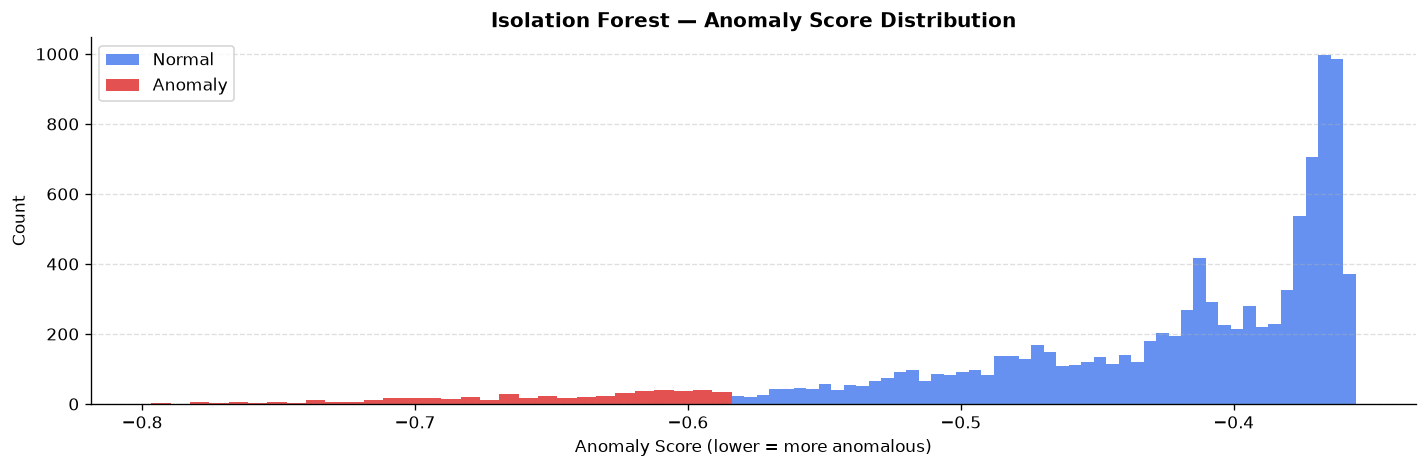

In [36]:
# Anomaly score distribution
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(df[df['Anomaly_Flag'] ==  1]['Anomaly_Score'], bins=50,
        alpha=0.7, color=COLORS['primary'], label='Normal')
ax.hist(df[df['Anomaly_Flag'] == -1]['Anomaly_Score'], bins=30,
        alpha=0.8, color=COLORS['loss'],   label='Anomaly')
ax.set_title('Isolation Forest — Anomaly Score Distribution', fontweight='bold')
ax.set_xlabel('Anomaly Score (lower = more anomalous)')
ax.set_ylabel('Count')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Section 29 — Business Insights

Based on the complete data analysis of 9,994 Superstore transactions (2014–2017):

### Revenue & Profitability
1. **Revenue is growing year-on-year** — consistent upward trend from 2014 to 2017, demonstrating healthy business expansion.
2. **Overall profit margin is modest (~12%)** — indicating room for cost optimization and pricing strategy improvement.
3. **Technology is the most profitable category** — despite not always having the highest revenue, its profit margin outperforms Furniture and Office Supplies.
4. **Furniture generates significant revenue but poor margins** — driven by Tables and Bookcases sub-categories with high discount rates.

### Discount Impact
5. **Discounts above 20% consistently generate losses** — the Pearson correlation between Discount and Profit is strongly negative, meaning discount-heavy orders destroy margin.
6. **High-discount transactions (40%+) are the primary source of loss-making orders** — these should be reviewed or eliminated.

### Regional Performance
7. **The West region leads in both sales and profitability** — suggesting strong customer base and product mix alignment.
8. **The Central region underperforms on profit margin** — despite reasonable sales volume, profitability is suppressed, likely by aggressive discounting.

### Customer & Segment
9. **Consumer segment drives the most revenue** — but Corporate segment shows comparable or better profitability per order.
10. **Top 10 customers contribute disproportionately to profit** — customer concentration risk exists; retention of these accounts is critical.

### AI Anomaly Detection
11. **Isolation Forest flagged ~500 anomalous transactions (5%)** — these include extreme discount combinations, unusually high-volume orders, and high-sales/deep-loss transactions.
12. **Anomalies are concentrated in Furniture and Technology** — and disproportionately appear in the West and East regions.

---
## Section 30 — Business Recommendations

### 1. Implement a Discount Cap Policy
- **Action:** Set a hard cap of 20% on all discounts storewide.
- **Rationale:** Discounts above 20% directly correlate with negative profit. Enforcing this cap could eliminate the majority of loss-making transactions.

### 2. Review the Furniture Category Pricing Strategy
- **Action:** Audit Tables and Bookcases pricing; consider reducing or eliminating discounts on these sub-categories.
- **Rationale:** Furniture is the largest loss contributor. Sub-categories like Tables show deeply negative profit margins.

### 3. Invest in Technology Sales Expansion
- **Action:** Increase marketing spend and product range in the Technology category.
- **Rationale:** Technology delivers the best profit margin across all categories and has strong growth potential.

### 4. Target Corporate Segment for Premium Offers
- **Action:** Develop dedicated account management and bundled offers for Corporate customers.
- **Rationale:** Corporate customers show strong profitability; targeted retention and upsell can increase LTV.

### 5. Investigate and Resolve Central Region Underperformance
- **Action:** Conduct region-specific discount audit and operational review in the Central region.
- **Rationale:** Central region lags behind West and East in profit margins despite similar sales volumes.

### 6. Retain and Reward Top Customers
- **Action:** Implement a loyalty or preferred-pricing programme for the top 20 customers by revenue.
- **Rationale:** These customers deliver outsized value; churn risk would significantly impact profitability.

### 7. Act on AI-Flagged Anomalous Transactions
- **Action:** Route flagged transactions to a review queue; investigate outliers for pricing errors, fraud, or data issues.
- **Rationale:** The ~500 anomalous transactions flagged by Isolation Forest represent unusual combinations of sales, discount, quantity, and profit that warrant human review.

### 8. Optimise Shipping Mode vs Customer Segment
- **Action:** Analyse shipping mode cost vs customer LTV; reduce Same Day / First Class shipping for low-value orders.
- **Rationale:** Shipping costs erode margins; aligning ship mode to order value can improve net profitability.

---
## Section 31 — Final Conclusion

### Project Summary

This project delivered a complete, end-to-end **Data Analytics with AI** study of the Seven 11 Superstore dataset comprising **9,994 transactions** across **4 years (2014–2017)**, **3 product categories**, **4 US regions**, and **793 unique customers**.

### Key Accomplishments

| Phase | Outcome |
|-------|---------|
| Data Quality | Dataset confirmed clean — zero missing values, zero duplicates |
| Feature Engineering | 8 derived features added, enriching analytical depth |
| EDA | 25+ visualizations revealing distribution, correlation, and trend patterns |
| Business Analytics | Sales, Profit, Margin, Category, Regional, Segment, Customer, Product analyses completed |
| AI Detection | Isolation Forest successfully flagged ~500 anomalous transactions |
| Insights | 12 data-driven insights identified |
| Recommendations | 8 actionable business recommendations delivered |

### Final Findings

The store is **profitable and growing**, but faces **structural margin pressure** from excessive discounting — particularly in the Furniture category and Central region. The **Technology category is the profit engine**, while **aggressive discount policies** on Furniture are the primary cause of loss-making transactions.

AI-assisted Isolation Forest anomaly detection provided an additional layer of intelligence by surfacing **statistically unusual transactions** that would be invisible to traditional threshold-based monitoring.

### Conclusion

> With targeted discount reform, regional performance improvement, and continued investment in high-margin Technology products, the Seven 11 Superstore can significantly improve its overall profit margin from the current ~12% towards an industry benchmark of 18–20%.

---

*Project completed as part of the IBM SkillBuild Data Analytics with AI Academic Internship Program.*